In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.datasets as dset
import torchvision.models as models
import torch.optim as optim
import torchvision.transforms as transforms
import time
import matplotlib.pyplot as plt
import numpy as np
import random

In [ ]:
### code inspired by https://zhuanlan.zhihu.com/p/322046843
batch_size = 64
input_size = 32
norm_mean = [0.485, 0.456, 0.406]
norm_std = [0.229, 0.224, 0.225]
transform=transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(norm_mean, norm_std),
])
dataset_path = './data/cifar10'

train_data = torchvision.datasets.CIFAR10(root=dataset_path, train=True,download=True, transform=transform)
test_data = torchvision.datasets.CIFAR10(root=dataset_path, train=False,download=True, transform=transform)
train_loader=torch.utils.data.DataLoader(train_data,batch_size=batch_size,shuffle=True)
test_loader=torch.utils.data.DataLoader(test_data,batch_size=batch_size,shuffle=True)
test_loader_1=torch.utils.data.DataLoader(test_data,batch_size=1,shuffle=True) # used for adversarial attack
n_train=len(train_data)
n_test=len(test_data)
classes = train_data.classes
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print('Using {} device'.format(device))

Files already downloaded and verified
Files already downloaded and verified
Using cpu device


In [3]:
def unnormalize(img, mean = np.array(norm_mean), std = np.array(norm_std)):
  '''
   unnormalize the image that has been normalized with mean and std
  '''
  inverse_mean = - mean/std
  inverse_std = 1/std
  img = transforms.Normalize(mean=-mean/std, std=1/std)(img)
  return img

def normalize(img, mean = np.array(norm_mean), std = np.array(norm_std)):
  return transforms.Normalize(mean = norm_mean, std = norm_std)(img)

In [5]:
def imshow(img, label):
    img = unnormalize(img)     # unnormalize
    plt.imshow(np.transpose(img, (1, 2, 0)))
    plt.title(classes[label])
    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2935183..1.7067103].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.3865546..1.5388304].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.35345495..1.6892812].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.39626682..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.3020807..1.6892812].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.25926882..1.3675828].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.34489256

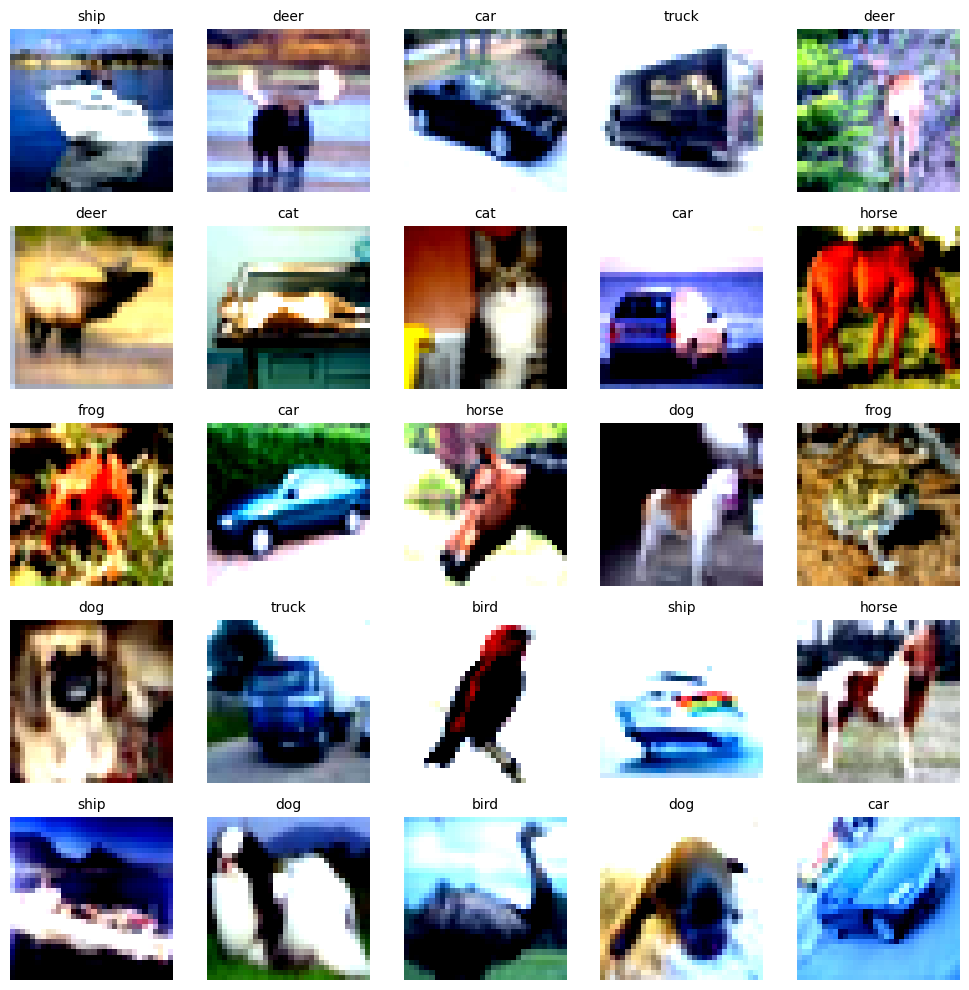

In [6]:
# # get some random training images
# image, label = test_data[0][0], test_data[0][1]

# # show images
# imshow(image, label)
import matplotlib.pyplot as plt
import torchvision.utils as vutils

# Classes in CIFAR-10 dataset
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# Function to display images with class names in a 5x5 grid
def imshow_grid(images, labels, num_images=25):
    # Set up a 5x5 grid of subplots
    fig, axes = plt.subplots(5, 5, figsize=(10, 10))
    axes = axes.flatten()

    # Loop over the number of images (max 25)
    for i in range(num_images):
        img = images[i]
        label = labels[i].item()

        # Unnormalize and permute the image for correct display
        img = img / 2 + 0.5  # unnormalize
        img = img.permute(1, 2, 0)  # convert from (C, H, W) to (H, W, C)

        # Display image and set title as class name
        axes[i].imshow(img)
        axes[i].set_title(classes[label], fontsize=10)
        axes[i].axis('off')

    # Remove unused subplots
    for ax in axes[num_images:]:
        ax.remove()

    plt.tight_layout()
    plt.show()

# Load a batch of images using DataLoader
images, labels = next(iter(test_loader))  # Assuming test_loader is your DataLoader

# Show 25 images (5x5 grid) with class names
imshow_grid(images, labels, num_images=25)


In [ ]:
def get_num_correct(out, labels):  
    return out.argmax(dim=1).eq(labels).sum().item()

In [ ]:
# model=models.resnet18(pretrained=True) 
model=models.vgg19(pretrained=True) 
model.classifier[-1]=nn.Linear(4096, len(classes)) 

model=model.to(device)
optimizer=torch.optim.SGD(model.parameters(),lr=0.01)


c:\Users\nissy\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\nissy\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [10]:
import time
import os
import torch
import torch.nn.functional as F

# Assuming these are defined: model, optimizer, train_loader, test_loader, device

# Number of epochs for training
epoch_num = 20
best_acc = 0  # To store the best test accuracy for saving the model
train_loss = []
test_loss = []
test_accuracy = []

# Directory for saving the model
model_save_path = 'C:/Users/nissy/Desktop/MAJOR/vgg19.pth'
if not os.path.exists(os.path.dirname(model_save_path)):
    os.makedirs(os.path.dirname(model_save_path))

# Getting the number of training and test samples
n_train = len(train_loader.dataset)
n_test = len(test_loader.dataset)

# Function to get the number of correct predictions
def get_num_correct(outs, labels):
    _, predicted = torch.max(outs, 1)
    return (predicted == labels).sum().item()

# Tracking the start time for training
since = time.time()

# Training loop
for epoch in range(epoch_num):
    print(f'Epoch {epoch + 1}/{epoch_num}')
    print('-' * 10)

    # Temporary variables to track loss and accuracy for the epoch
    train_loss_tmp = 0
    test_loss_tmp = 0
    test_accuracy_tmp = 0

    # Training phase
    model.train()  # Set model to training mode
    for batch, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        outs = model(images)
        loss = F.cross_entropy(outs, labels)
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Accumulate training loss
        train_loss_tmp += loss.item()

        # Log progress every 100 batches
        if batch % 100 == 0:
            loss_value = loss.item()
            current = batch * len(images)
            print(f"loss: {loss_value:.6f}  [{current:>5d}/{n_train:>5d}]")

    # Normalize the training loss for the epoch
    train_loss_tmp /= n_train

    # Validation phase (no gradient computation)
    model.eval()  # Set model to evaluation mode
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            
            # Forward pass
            outs = model(images)
            
            # Accumulate test loss
            test_loss_tmp += F.cross_entropy(outs, labels).item()
            
            # Calculate number of correct predictions
            test_accuracy_tmp += get_num_correct(outs, labels)

    # Normalize the test loss and accuracy
    test_loss_tmp /= n_test
    test_accuracy_tmp /= n_test  # Accuracy is a percentage

    # Append loss and accuracy to lists for tracking
    train_loss.append(train_loss_tmp)
    test_loss.append(test_loss_tmp)
    test_accuracy.append(test_accuracy_tmp)

    # Save the model if test accuracy improves
    if test_accuracy_tmp > best_acc:
        torch.save(model, model_save_path)
        best_acc = test_accuracy_tmp

    # Print test accuracy and loss after each epoch
    print(f"Test Error: \n Accuracy: {(100 * test_accuracy_tmp):>0.1f}%, Avg loss: {test_loss_tmp:.6f}\n")

# Calculate total training time
time_elapsed = time.time() - since
print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')


Epoch 1/20
----------
loss: 2.737588  [    0/50000]
loss: 0.721502  [ 6400/50000]
loss: 0.988112  [12800/50000]
loss: 0.613638  [19200/50000]
loss: 0.505264  [25600/50000]
loss: 0.612942  [32000/50000]
loss: 0.728843  [38400/50000]
loss: 0.506987  [44800/50000]
Test Error: 
 Accuracy: 73.1%, Avg loss: 0.012836

Epoch 2/20
----------
loss: 0.805861  [    0/50000]
loss: 0.479503  [ 6400/50000]
loss: 0.326925  [12800/50000]
loss: 0.622208  [19200/50000]
loss: 0.447636  [25600/50000]
loss: 0.412102  [32000/50000]
loss: 0.475663  [38400/50000]
loss: 0.405267  [44800/50000]
Test Error: 
 Accuracy: 73.7%, Avg loss: 0.013978

Epoch 3/20
----------
loss: 0.624860  [    0/50000]
loss: 0.368702  [ 6400/50000]
loss: 0.468604  [12800/50000]
loss: 0.262379  [19200/50000]
loss: 0.194490  [25600/50000]
loss: 0.281086  [32000/50000]
loss: 0.330958  [38400/50000]
loss: 0.367582  [44800/50000]
Test Error: 
 Accuracy: 85.0%, Avg loss: 0.006936

Epoch 4/20
----------
loss: 0.251055  [    0/50000]
loss: 0.2

In [ ]:

model = torch.load(model_save_path, map_location='cpu')
model=model.to(device)
model.eval()

C:\Users\nissy\AppData\Local\Temp\ipykernel_13708\27432150.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(model_save_path, map_location='cpu')


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

In [12]:
test_accuracy = 0
with torch.no_grad():
  for (images,labels) in test_loader:
      images,labels = images.to(device),labels.to(device)
      outs = model(images)
      test_accuracy += get_num_correct(outs,labels)
test_accuracy /= n_test
print(f"Accuracy of the trained vgg19 model: {(100*test_accuracy):>0.1f}%")

Accuracy of the trained vgg19 model: 89.8%


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.44764107..1.7938564].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.7502832].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5247024..1.7938564].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.24214405..1.6369936].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.49901533..1.4079132].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4828431..1.2477095].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5503

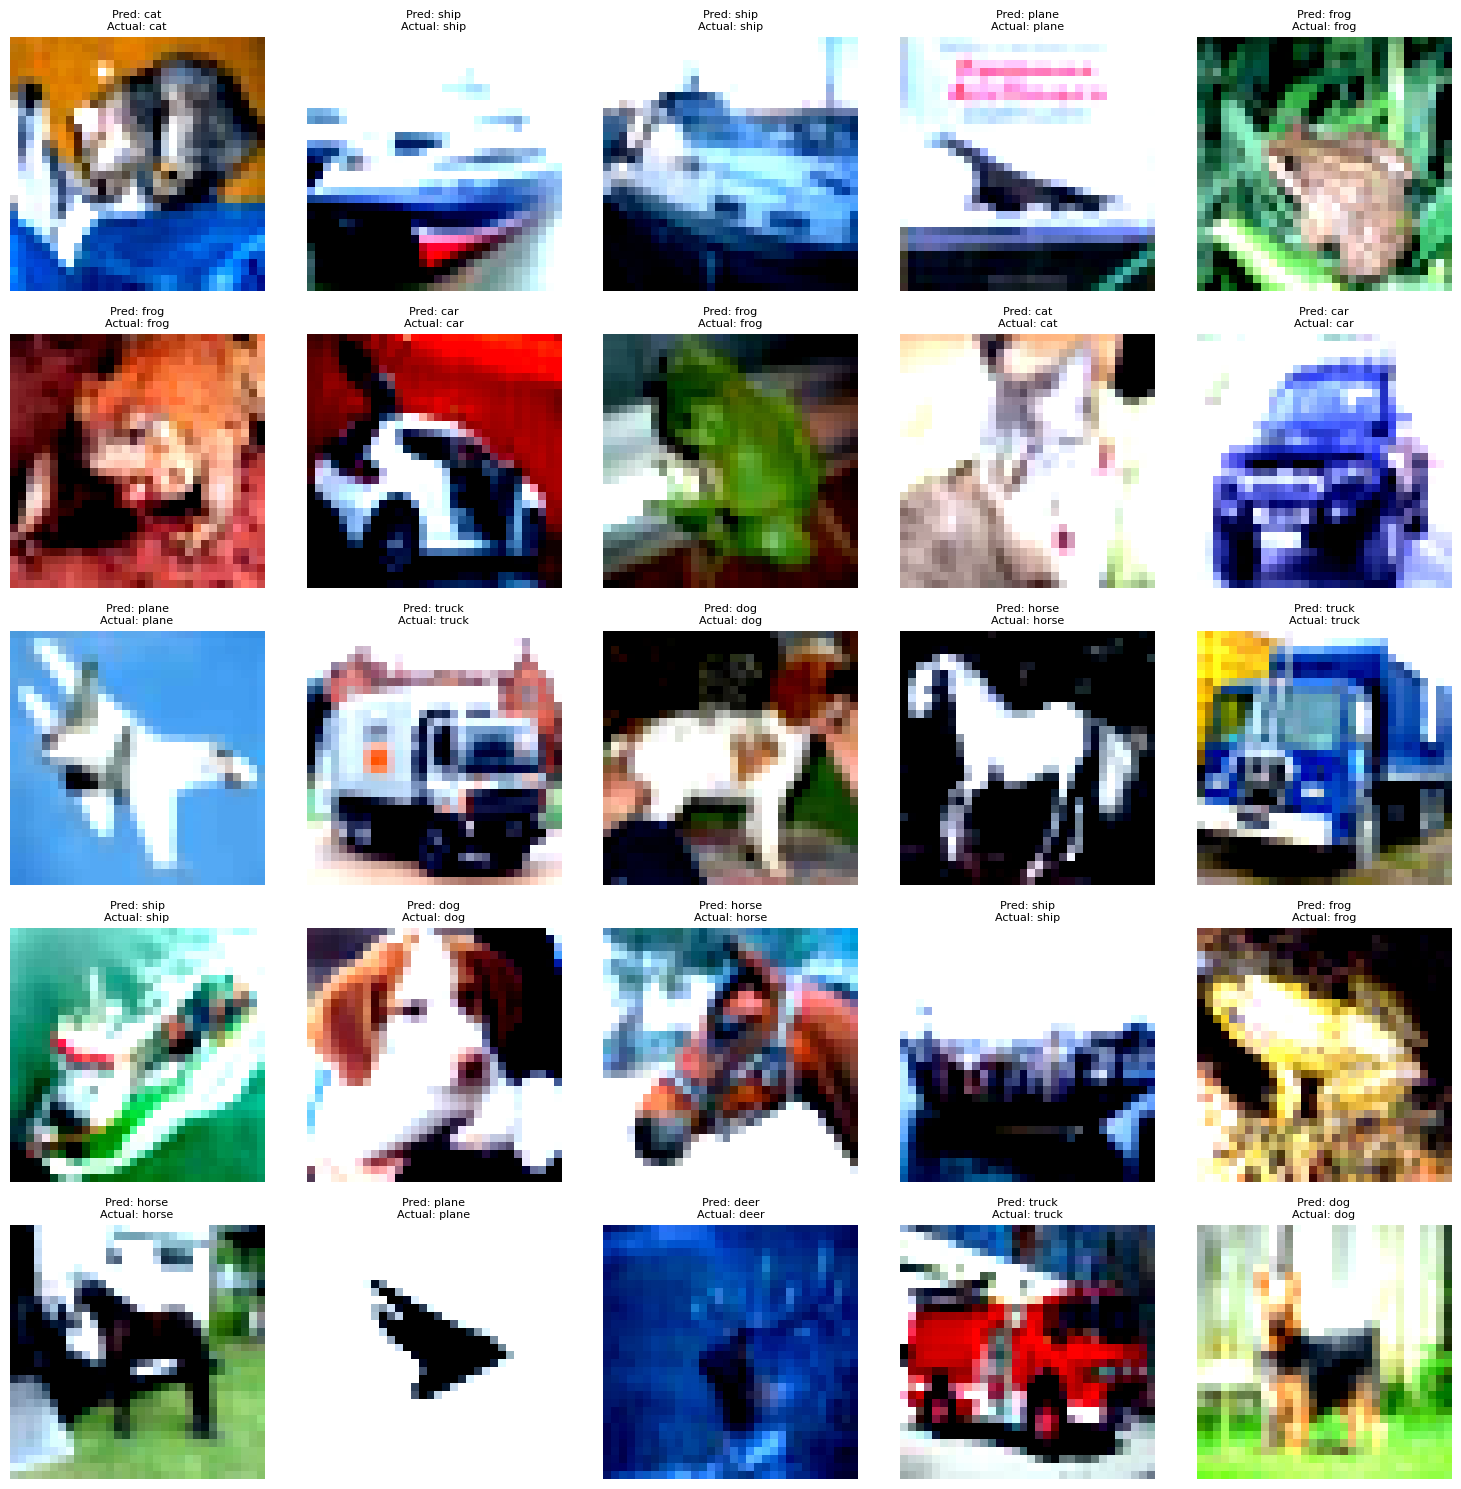

In [16]:

def imshow(img, ax, predicted, actual):
    # Unnormalize the image for better visualization if it's normalized
    img = img / 2 + 0.5  # example normalization reversal
    npimg = img.numpy()
    ax.imshow(np.transpose(npimg, (1, 2, 0)))
    ax.set_title(f'Pred: {classes[predicted]}\nActual: {classes[actual]}', fontsize=8)
    ax.axis('off')  # Hide axis for a cleaner look

# Get multiple images from the test set and show in a 5x4 grid
def predict_and_show_grid(model, test_data, rows=5, cols=4):
    model.eval()  # Ensure the model is in evaluation mode
    fig, axs = plt.subplots(rows, cols, figsize=(15, 15))  # Create a 5x4 grid of subplots
    
    count = 0
    with torch.no_grad():
        for i in range(rows):
            for j in range(cols):
                if count >= len(test_data):
                    break
                
                x, y = test_data[count][0], test_data[count][1]
                x = torch.unsqueeze(x, dim=0).float().to(device)
                
                # Make prediction
                pred = model(x)
                predicted = pred[0].argmax(0).item()
                actual = y
                
                # Squeeze image back and send it to CPU for visualization
                x = x.squeeze().cpu()
                
                # Display each image in its corresponding subplot
                imshow(x, axs[i, j], predicted, actual)
                
                count += 1
    
    plt.tight_layout()  # Adjust layout for better spacing
    plt.show()

# Example usage:
predict_and_show_grid(model, test_data, rows=5, cols=5)


FGSM ATTACK

\begin{align}perturbed\_image = image + epsilon*sign(data\_grad) = x + \epsilon * sign(\nabla_{x} J(\mathbf{\theta}, \mathbf{x}, y))\end{align}

In [17]:
def fgsm_attack(image, epsilon, data_grad):
  if epsilon == 0:
    return image
  else:
    image = unnormalize(image)
    pertubed_image = image + epsilon*data_grad.sign()
    pertubed_image = torch.clamp(pertubed_image,0,1)
    pertubed_image = transforms.Normalize(mean = norm_mean, std = norm_std)(pertubed_image)
    return pertubed_image.float()

In [ ]:
def fgsm_test(model, data_loader, epsilon, n_examples):
  '''
  input: 
    data_loader: data set, batch size = 1
    epsilon: parameter to perform fgsm attack
  return:
    final_acc: accuracy of the model on classifying adversarial examples created based on datas
    adv_examples: n_examples examples of successed adversrial examples
  '''
  print('Epsilon:', epsilon)
  print('-' * 10)
  correct = 0
  adv_examples = []
  # Loop over all examples in data set, data shape: (C, H, W)
  for i, (data, target) in enumerate(data_loader):

      if i>0 and i%1000 == 0:
        current_acc = correct/i
        print(f'Test Accuracy = {current_acc:.4f} [{i:>5d} / {len(data_loader):>5d}]')

      # Send the data and label to the device
      data, target = data.to(device), target.to(device)

      # Set requires_grad attribute of tensor. Important for Attack
      data.requires_grad = True

      # Forward pass the data through the model
      output = model(data)
      init_pred = output.max(1, keepdim=True)[1] # get the index of the max log-probability
      # If the initial prediction is wrong, dont bother attacking, just move on
      if init_pred.item() != target.item():
          continue

      # Calculate the loss
      loss = F.nll_loss(output, target)

      # Zero all existing gradients
      model.zero_grad()

      # Calculate gradients of model in backward pass
      loss.backward()

      # Collect datagrad
      data_grad = data.grad.data

      # Call FGSM Attack
      perturbed_data = fgsm_attack(data, epsilon, data_grad)

      # Re-classify the perturbed image
      output = model(perturbed_data)

      # Check for success
      final_pred = output.max(1, keepdim=True)[1] # get the index of the max log-probability
      if final_pred.item() == target.item():
          correct += 1
          # Special case for saving 0 epsilon examples
          if (epsilon == 0) and (len(adv_examples) < n_examples):
              adv_ex = perturbed_data.squeeze().detach().cpu()
              ori_ex = data.squeeze().detach().cpu()
              adv_examples.append( (init_pred.item(), final_pred.item(), adv_ex, ori_ex) )
      else:
          # Save some adv examples for visualization later
          if len(adv_examples) < n_examples:
              adv_ex = perturbed_data.squeeze().detach().cpu()
              ori_ex = data.squeeze().detach().cpu()
              adv_examples.append( (init_pred.item(), final_pred.item(), adv_ex, ori_ex) )
      


  # Calculate final accuracy for this epsilon
  final_acc = correct/float(len(data_loader))
  print("Epsilon: {}\tTest Accuracy = {} / {} = {} \n".format(epsilon, correct, len(data_loader), final_acc))

  # Return the accuracy and an adversarial example
  return final_acc, adv_examples

In [27]:
epsilons = [0.001, 0.01, 0.02, 0.03, 0.04]  # Updated epsilon values
n_examples = 25
examples = []
accuracies = []

# Run test for each epsilon
for eps in epsilons:
    acc, ex = fgsm_test(model, test_loader_1, eps, n_examples)
    accuracies.append(acc)
    examples.append(ex)



Epsilon: 0.001
----------
Test Accuracy = 0.8270 [ 1000 / 10000]
Test Accuracy = 0.8350 [ 2000 / 10000]
Test Accuracy = 0.8360 [ 3000 / 10000]
Test Accuracy = 0.8325 [ 4000 / 10000]
Test Accuracy = 0.8330 [ 5000 / 10000]
Test Accuracy = 0.8308 [ 6000 / 10000]
Test Accuracy = 0.8299 [ 7000 / 10000]
Test Accuracy = 0.8290 [ 8000 / 10000]
Test Accuracy = 0.8291 [ 9000 / 10000]
Epsilon: 0.001	Test Accuracy = 8275 / 10000 = 0.8275 

Epsilon: 0.01
----------
Test Accuracy = 0.3600 [ 1000 / 10000]
Test Accuracy = 0.3490 [ 2000 / 10000]
Test Accuracy = 0.3563 [ 3000 / 10000]
Test Accuracy = 0.3488 [ 4000 / 10000]
Test Accuracy = 0.3422 [ 5000 / 10000]
Test Accuracy = 0.3402 [ 6000 / 10000]
Test Accuracy = 0.3384 [ 7000 / 10000]
Test Accuracy = 0.3396 [ 8000 / 10000]
Test Accuracy = 0.3406 [ 9000 / 10000]
Epsilon: 0.01	Test Accuracy = 3403 / 10000 = 0.3403 

Epsilon: 0.02
----------
Test Accuracy = 0.1880 [ 1000 / 10000]
Test Accuracy = 0.1750 [ 2000 / 10000]
Test Accuracy = 0.1777 [ 3000 / 100

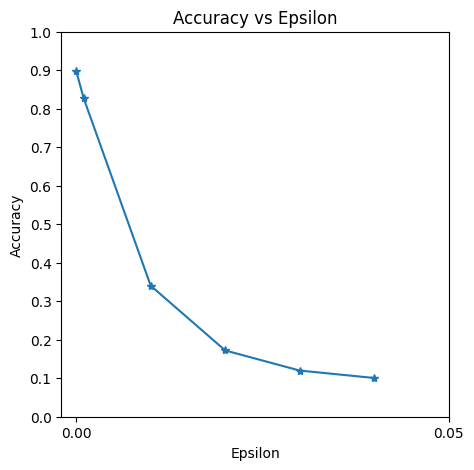

In [30]:
plt.figure(figsize=(5,5))
plt.plot([0] + epsilons, [test_accuracy] + accuracies, "*-")
plt.yticks(np.arange(0, 1.1, step=0.1))
plt.xticks(np.arange(0, .10, step=0.05))
plt.title("Accuracy vs Epsilon")
plt.xlabel("Epsilon")
plt.ylabel("Accuracy")
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.35345495..1.6457081].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.35154063..1.5411329].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.47332823..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4565826..1.5816423].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.13939553..1.4365578].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.20789456..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5332649..1.

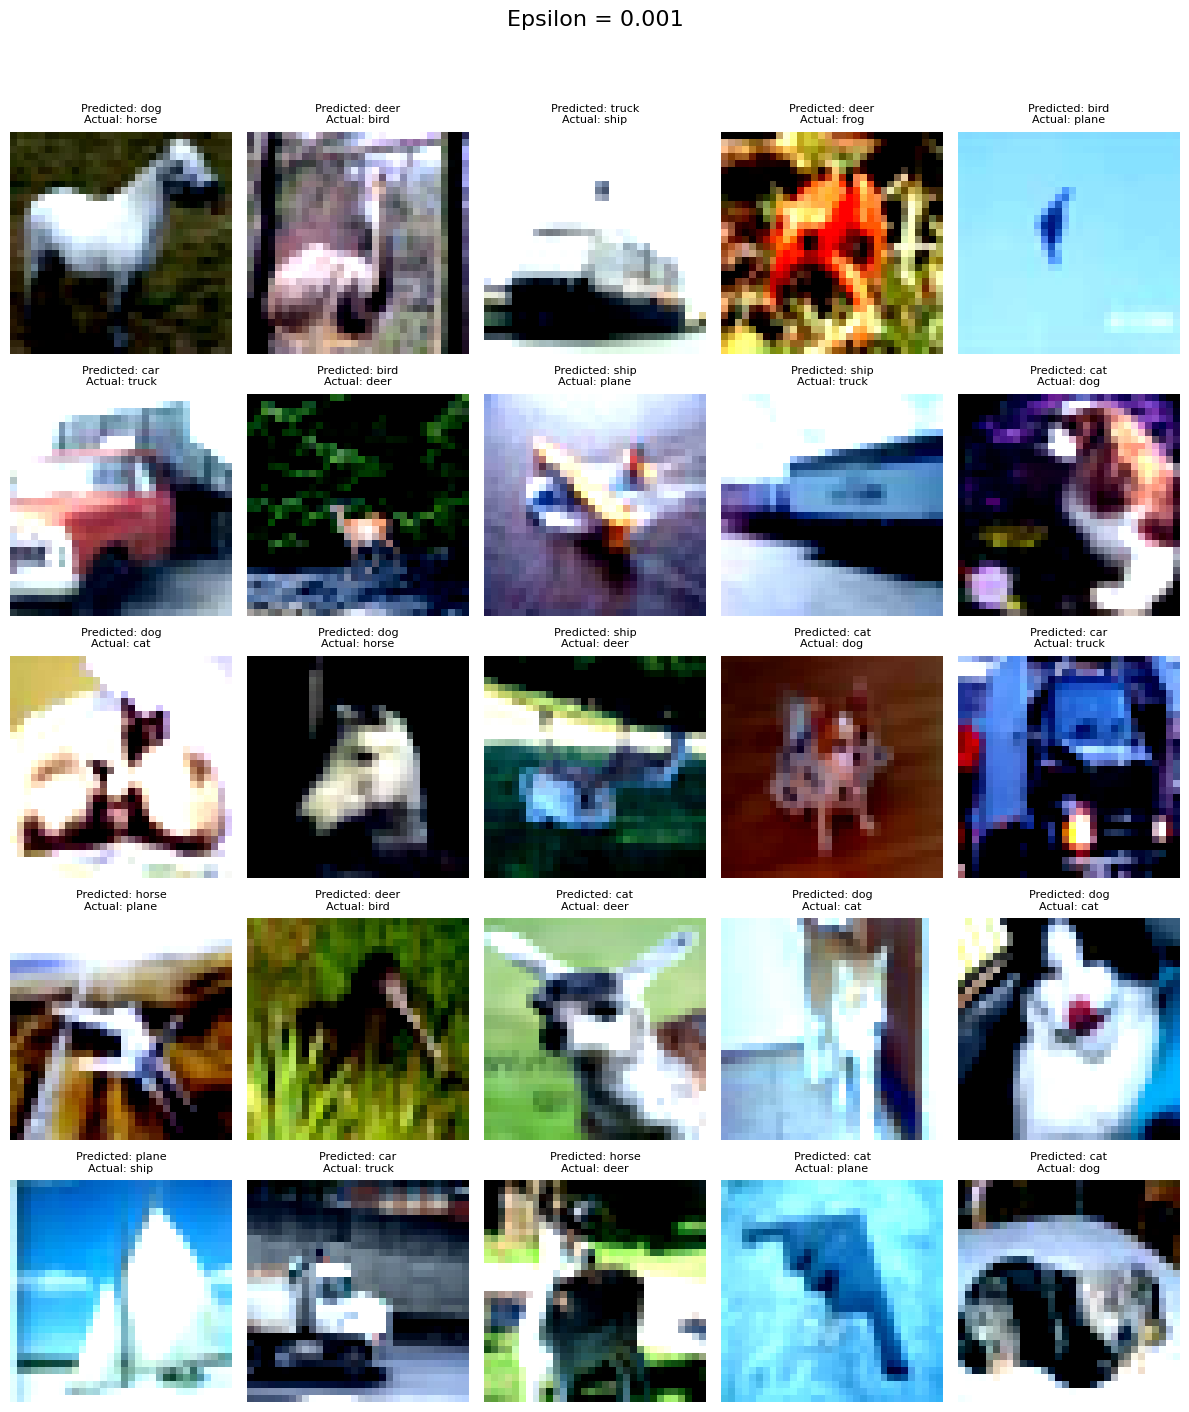

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.47408962..1.6244541].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5178571..1.7067103].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5075778..1.0227592].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.55038965..1.8112855].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.44764107..1.6544228].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5418272..1.7502832].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.456

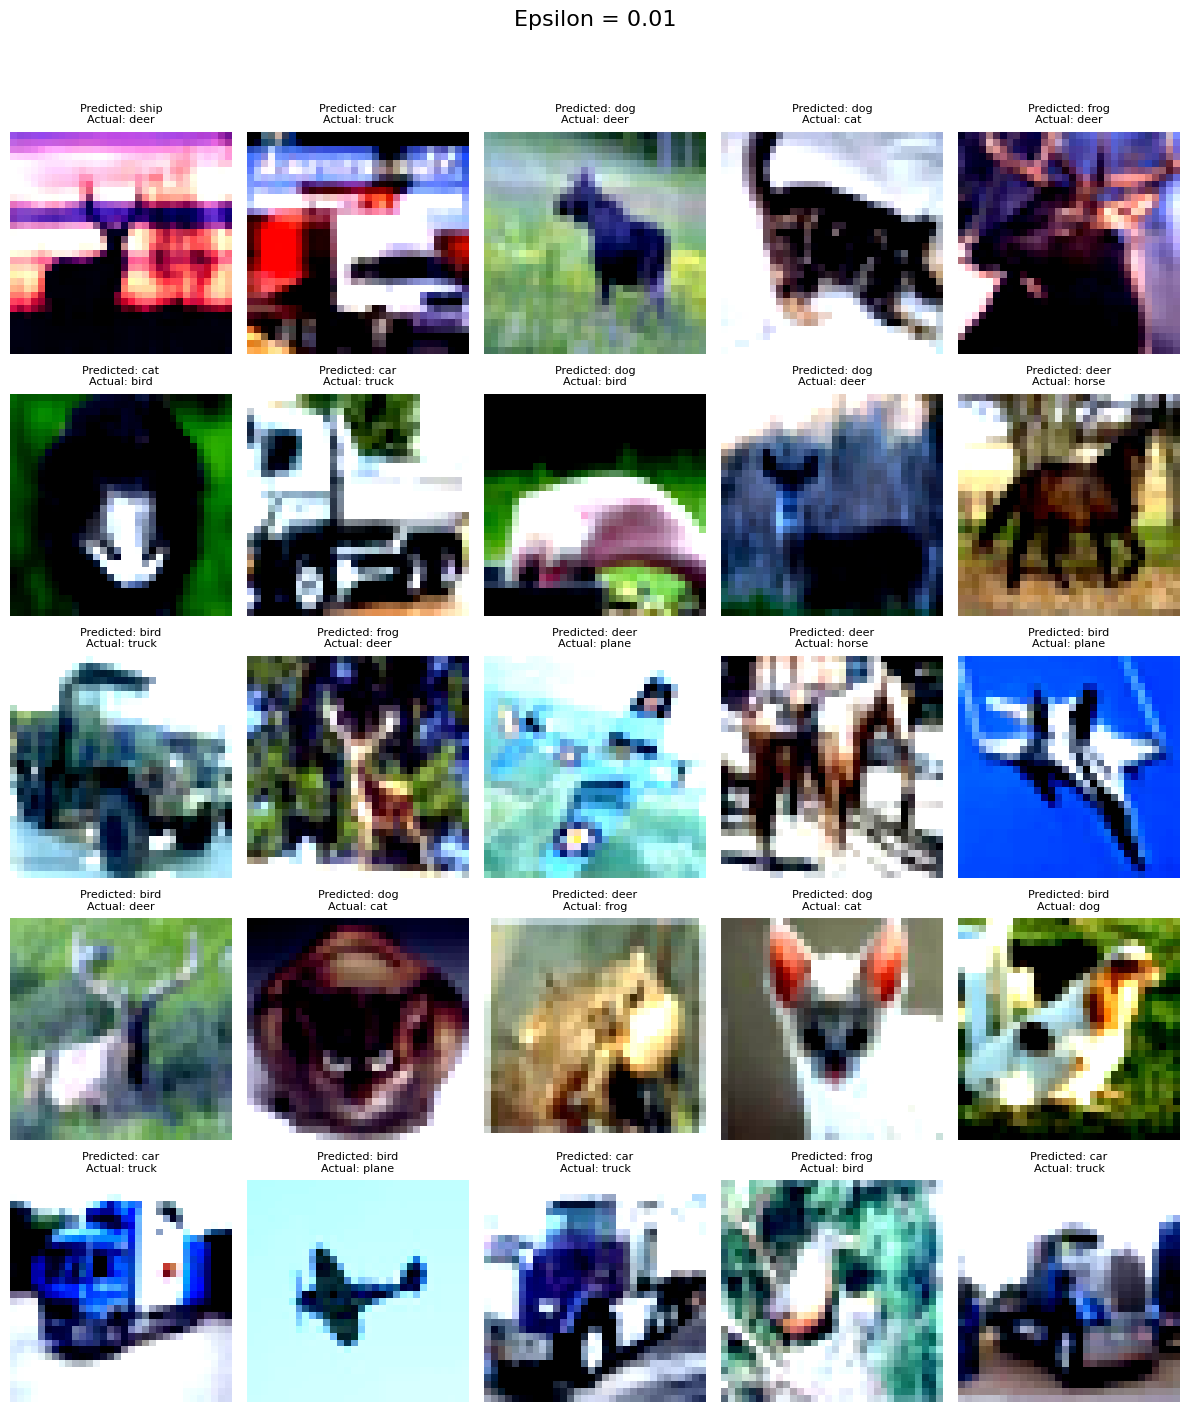

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5075778..1.6805664].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.1565203..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5332649..1.5730798].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5247024..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.47332823..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.3340336..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.42195398..1.82].
Clipping

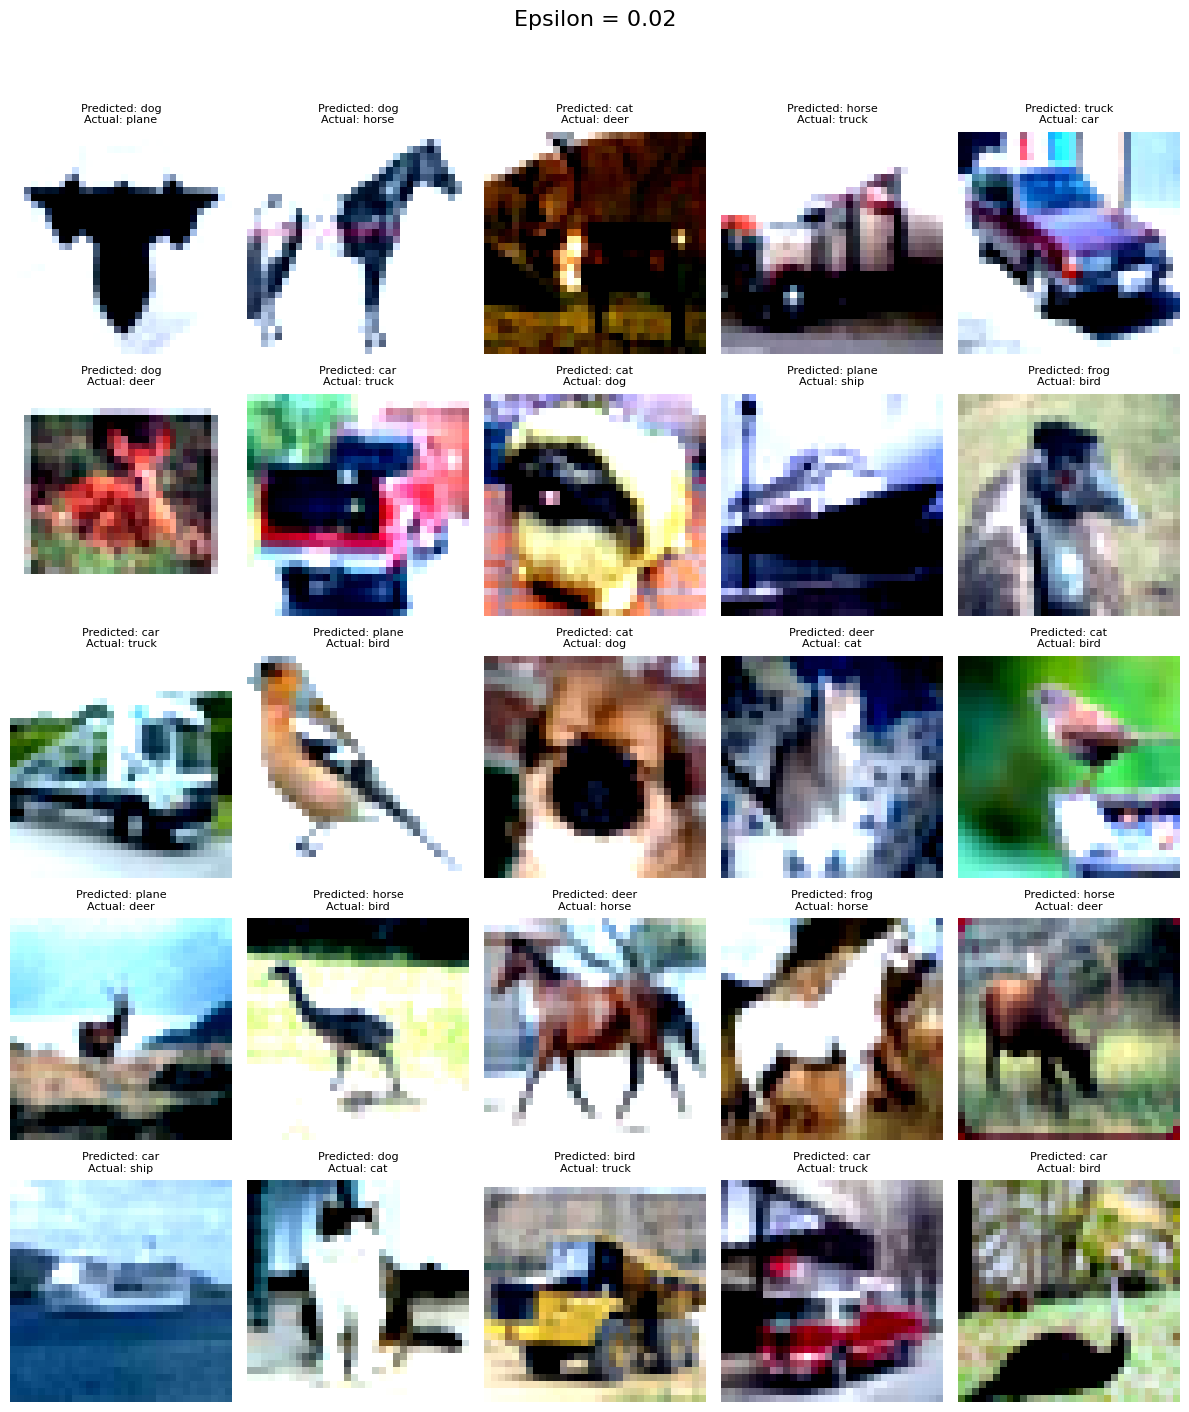

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2279303..1.5388304].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.7677125].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.30636168..1.6244541].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.38770443..1.7067103].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.46476585..1.7677125].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.32528007..1.5411329].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.430

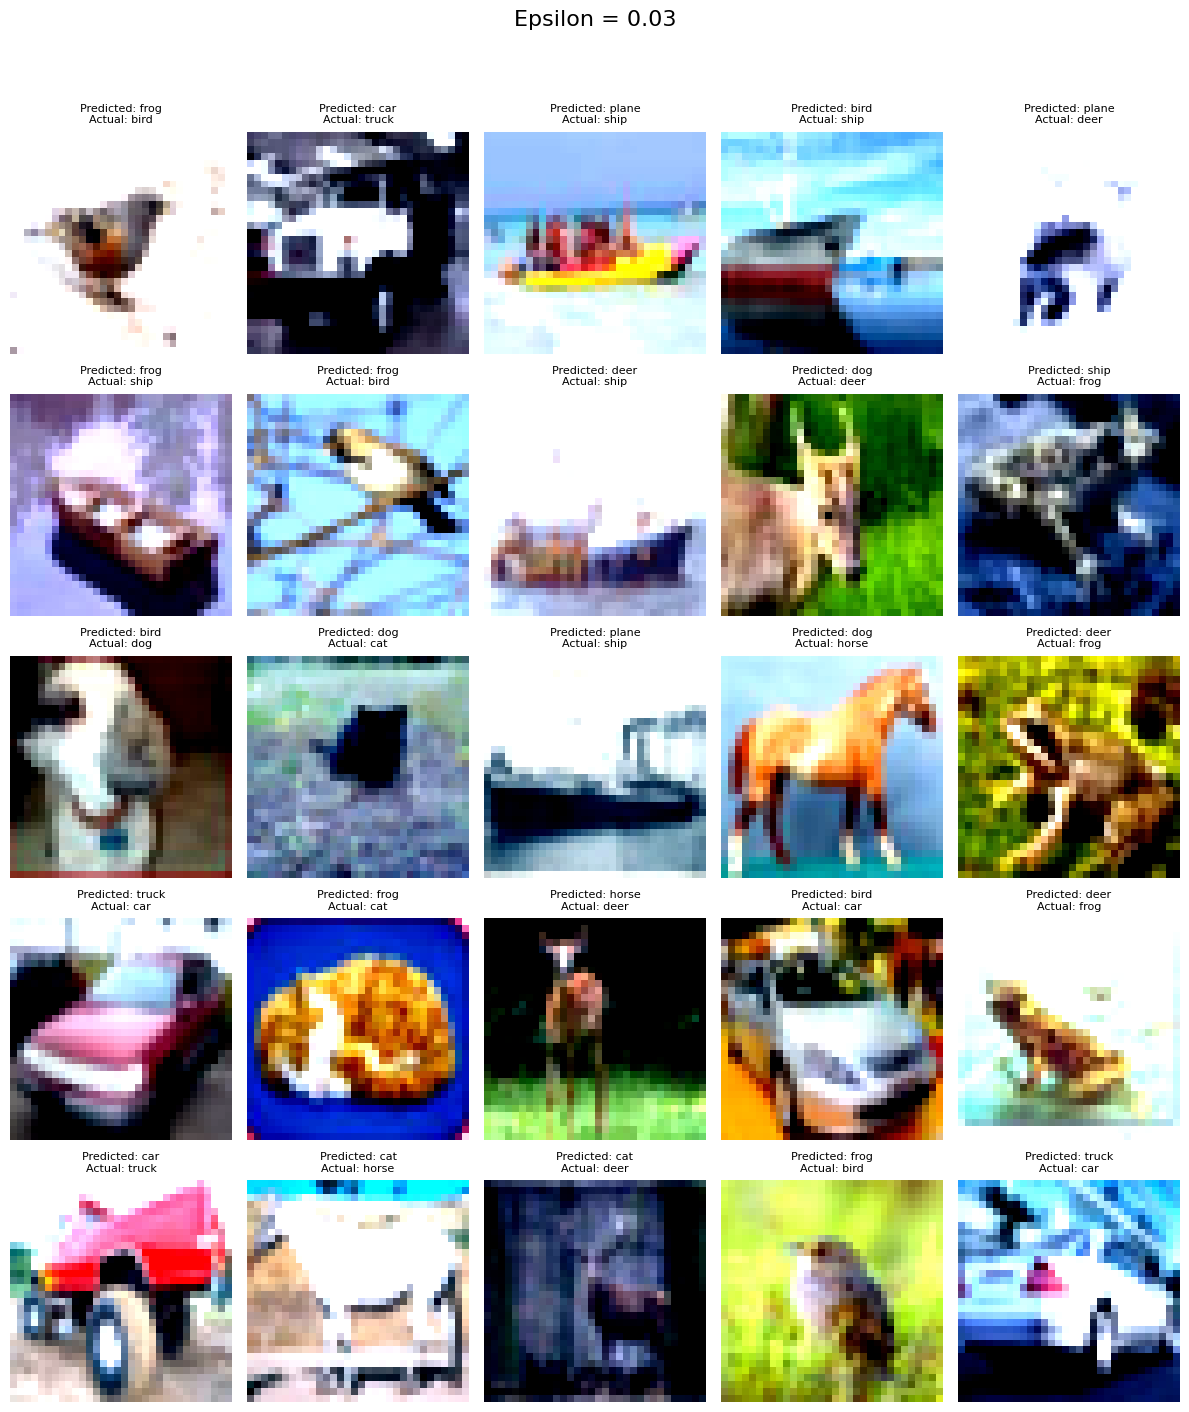

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.49901533..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.48189062..1.3145535].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.45620346..1.732854].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5178571..1.7764271].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.47408962..1.8025708].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.7502832].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.39626682.

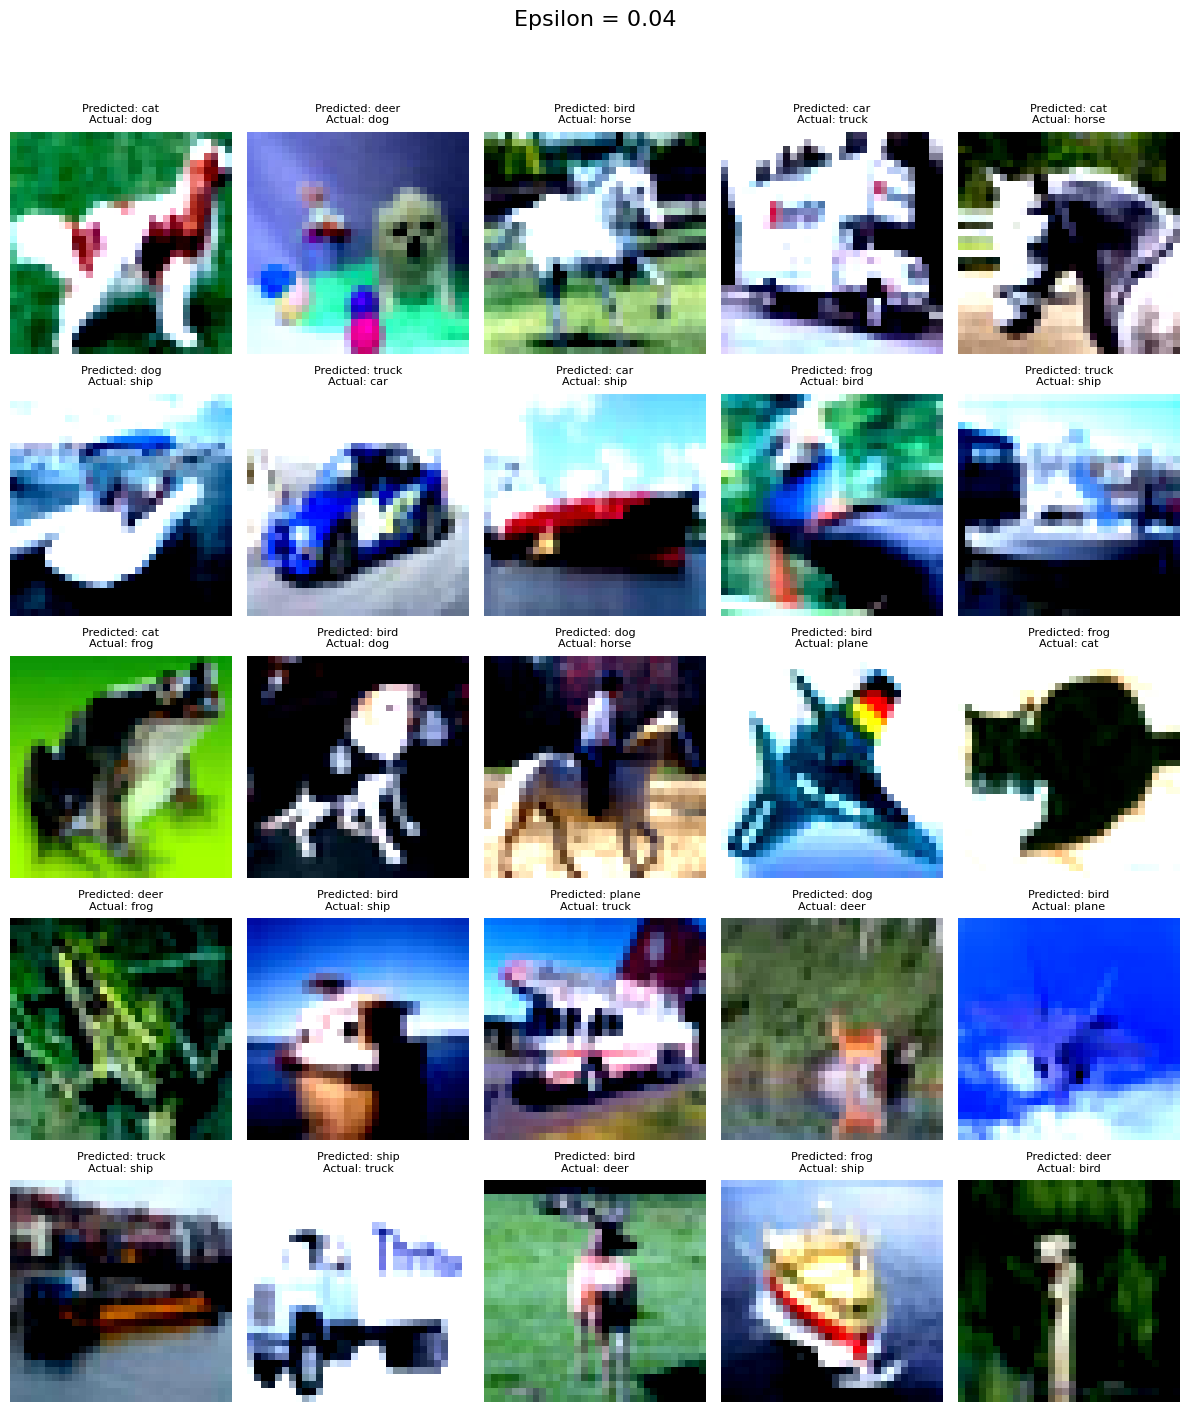

In [34]:

def ax_imshow(ax, img, predicted, actual):
    # Unnormalize the image if it was normalized
    img = img / 2 + 0.5  # Reversing normalization (if applicable)
    npimg = img.numpy()
    ax.imshow(np.transpose(npimg, (1, 2, 0)))
    
    # Display class names instead of numeric labels
    predicted_class = classes[predicted]
    actual_class = classes[actual]
    
    ax.set_title(f'Predicted: {predicted_class}\nActual: {actual_class}', fontsize=8)
    ax.axis('off')

# Display 5x5 matrix of original images with predicted and actual labels for each epsilon
for i, epsilon in enumerate(epsilons):
    fig, axs = plt.subplots(5, 5, figsize=(12, 15))  # Create 5x5 grid (not 5x4 as in your request)
    fig.suptitle(f"Epsilon = {epsilon}", fontsize=16)
    
    # Iterate over the examples for each epsilon
    for j in range(len(examples[i])): 
        orig, adv, adv_ex, ori_ex = examples[i][j]
        
        # Plot the original image
        ax = axs[j // 5, j % 5]  # Calculate position in grid
        
        # Display original image with both predicted and actual class names
        ax_imshow(ax, ori_ex, predicted=adv, actual=orig)  # Predicted label from adversarial, actual label from original
        
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout for better spacing
    plt.show()


In [35]:
def ifgsm_attack(image, epsilon, data_grad, alpha, num_iter):
    # Copy the original image
    perturbed_image = image.clone()

    for i in range(num_iter):
        # Ensure the image is normalized for each iteration
        perturbed_image = unnormalize(perturbed_image)

        # Compute the sign of the gradient
        perturbed_image = perturbed_image + alpha * data_grad.sign()

        # Clip the perturbation to maintain within the allowed epsilon bounds
        perturbation = torch.clamp(perturbed_image - image, min=-epsilon, max=epsilon)
        perturbed_image = image + perturbation

        # Re-normalize the image to maintain its integrity within the input space
        perturbed_image = torch.clamp(perturbed_image, 0, 1)  # Ensure pixel values are valid
        perturbed_image = transforms.Normalize(mean=norm_mean, std=norm_std)(perturbed_image)

    return perturbed_image.float()


In [36]:
def ifgsm_test(model, data_loader, epsilon, n_examples, alpha, num_iter):
    '''
    input: 
      model: the model to test
      data_loader: data set, batch size = 1
      epsilon: maximum perturbation to perform ifgsm attack
      alpha: step size for each iteration of ifgsm
      num_iter: number of iterations for the attack
      n_examples: number of examples to save for visualization
    return:
      final_acc: accuracy of the model on classifying adversarial examples created
      adv_examples: n_examples examples of successful adversarial examples
    '''
    print('Epsilon:', epsilon)
    print('-' * 10)
    correct = 0
    adv_examples = []
    
    # Loop over all examples in the data set, data shape: (C, H, W)
    for i, (data, target) in enumerate(data_loader):
        
        if i > 0 and i % 1000 == 0:
            current_acc = correct / i
            print(f'Test Accuracy = {current_acc:.4f} [{i:>5d} / {len(data_loader):>5d}]')

        # Send the data and label to the device
        data, target = data.to(device), target.to(device)

        # Set requires_grad attribute of tensor. Important for Attack
        data.requires_grad = True

        # Forward pass the data through the model
        output = model(data)
        init_pred = output.max(1, keepdim=True)[1]  # get the index of the max log-probability

        # If the initial prediction is wrong, skip the attack
        if init_pred.item() != target.item():
            continue

        # Calculate the loss
        loss = F.nll_loss(output, target)

        # Zero all existing gradients
        model.zero_grad()

        # Calculate gradients of model in backward pass
        loss.backward()

        # Collect the gradients
        data_grad = data.grad.data

        # Call I-FGSM Attack
        perturbed_data = ifgsm_attack(data, epsilon, data_grad, alpha, num_iter)

        # Re-classify the perturbed image
        output = model(perturbed_data)

        # Check for success
        final_pred = output.max(1, keepdim=True)[1]  # get the index of the max log-probability
        if final_pred.item() == target.item():
            correct += 1
            # Special case for saving 0 epsilon examples
            if (epsilon == 0) and (len(adv_examples) < n_examples):
                adv_ex = perturbed_data.squeeze().detach().cpu()
                ori_ex = data.squeeze().detach().cpu()
                adv_examples.append((init_pred.item(), final_pred.item(), adv_ex, ori_ex))
        else:
            # Save some adversarial examples for visualization later
            if len(adv_examples) < n_examples:
                adv_ex = perturbed_data.squeeze().detach().cpu()
                ori_ex = data.squeeze().detach().cpu()
                adv_examples.append((init_pred.item(), final_pred.item(), adv_ex, ori_ex))

    # Calculate final accuracy for this epsilon
    final_acc = correct / float(len(data_loader))
    print(f"Epsilon: {epsilon}\tTest Accuracy = {correct} / {len(data_loader)} = {final_acc}\n")

    # Return the accuracy and a list of adversarial examples
    return final_acc, adv_examples


In [38]:
epsilons = [0.001, 0.01, 0.02, 0.03, 0.04]  # Updated epsilon values
n_examples = 25
examples = []
accuracies = []

# Parameters for I-FGSM
alpha = 0.005  # Step size for each iteration
num_iter = 10  # Number of iterations for I-FGSM

# Run test for each epsilon using I-FGSM
for eps in epsilons:
    acc, ex = ifgsm_test(model, test_loader_1, eps, n_examples, alpha, num_iter)
    accuracies.append(acc)
    examples.append(ex)

Epsilon: 0.001
----------
Test Accuracy = 0.5960 [ 1000 / 10000]
Test Accuracy = 0.5900 [ 2000 / 10000]
Test Accuracy = 0.5893 [ 3000 / 10000]
Test Accuracy = 0.5863 [ 4000 / 10000]
Test Accuracy = 0.5904 [ 5000 / 10000]
Test Accuracy = 0.5918 [ 6000 / 10000]
Test Accuracy = 0.5906 [ 7000 / 10000]
Test Accuracy = 0.5890 [ 8000 / 10000]
Test Accuracy = 0.5900 [ 9000 / 10000]
Epsilon: 0.001	Test Accuracy = 5886 / 10000 = 0.5886

Epsilon: 0.01
----------
Test Accuracy = 0.5670 [ 1000 / 10000]
Test Accuracy = 0.5675 [ 2000 / 10000]
Test Accuracy = 0.5667 [ 3000 / 10000]
Test Accuracy = 0.5633 [ 4000 / 10000]
Test Accuracy = 0.5620 [ 5000 / 10000]
Test Accuracy = 0.5632 [ 6000 / 10000]
Test Accuracy = 0.5621 [ 7000 / 10000]
Test Accuracy = 0.5619 [ 8000 / 10000]
Test Accuracy = 0.5598 [ 9000 / 10000]
Epsilon: 0.01	Test Accuracy = 5580 / 10000 = 0.558

Epsilon: 0.02
----------
Test Accuracy = 0.5130 [ 1000 / 10000]
Test Accuracy = 0.5340 [ 2000 / 10000]
Test Accuracy = 0.5207 [ 3000 / 10000]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.5498476].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.47332823..1.8025708].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4390787..1.3145535].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.47332823..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.46476585..1.4627016].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.35154063..0.931

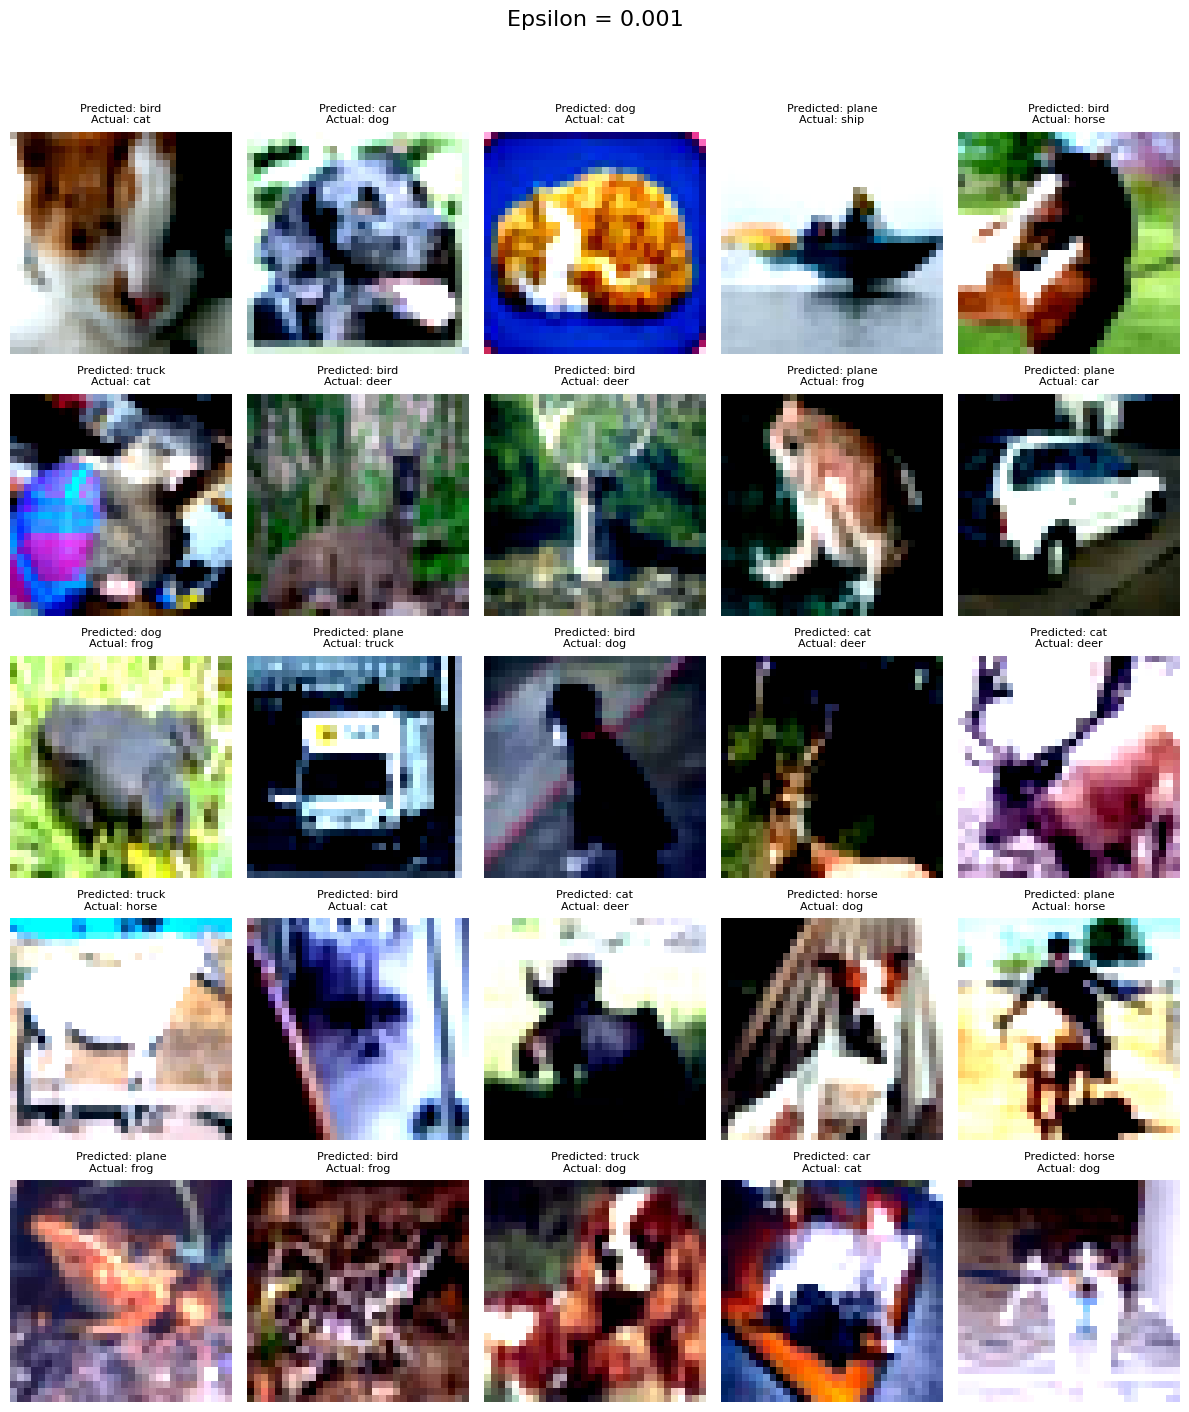

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.49901533..1.6617647].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.49901533..1.5388304].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.21148455..1.671852].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.37780112..1.279695].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.38770443..1.3581264].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5418272..1.6244541].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558

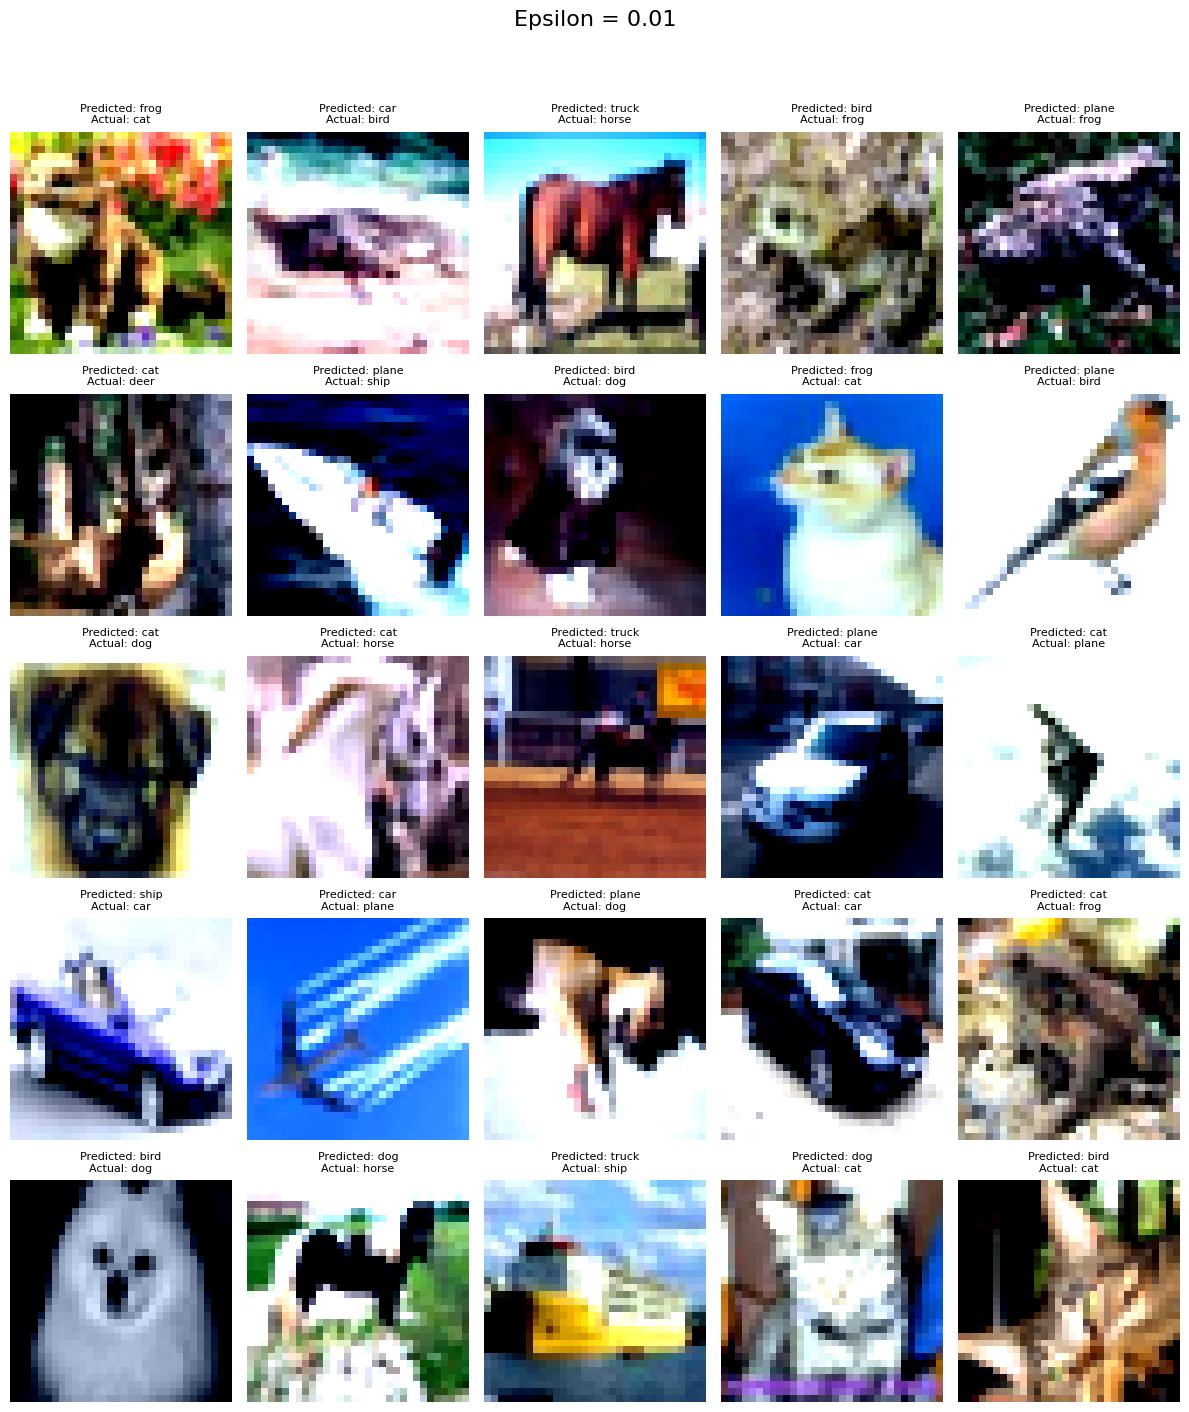

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.6021352].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5332649..1.6244541].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5332649..1.5062746].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.36201733..1.6617647].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.31064308..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.490453..0.965151

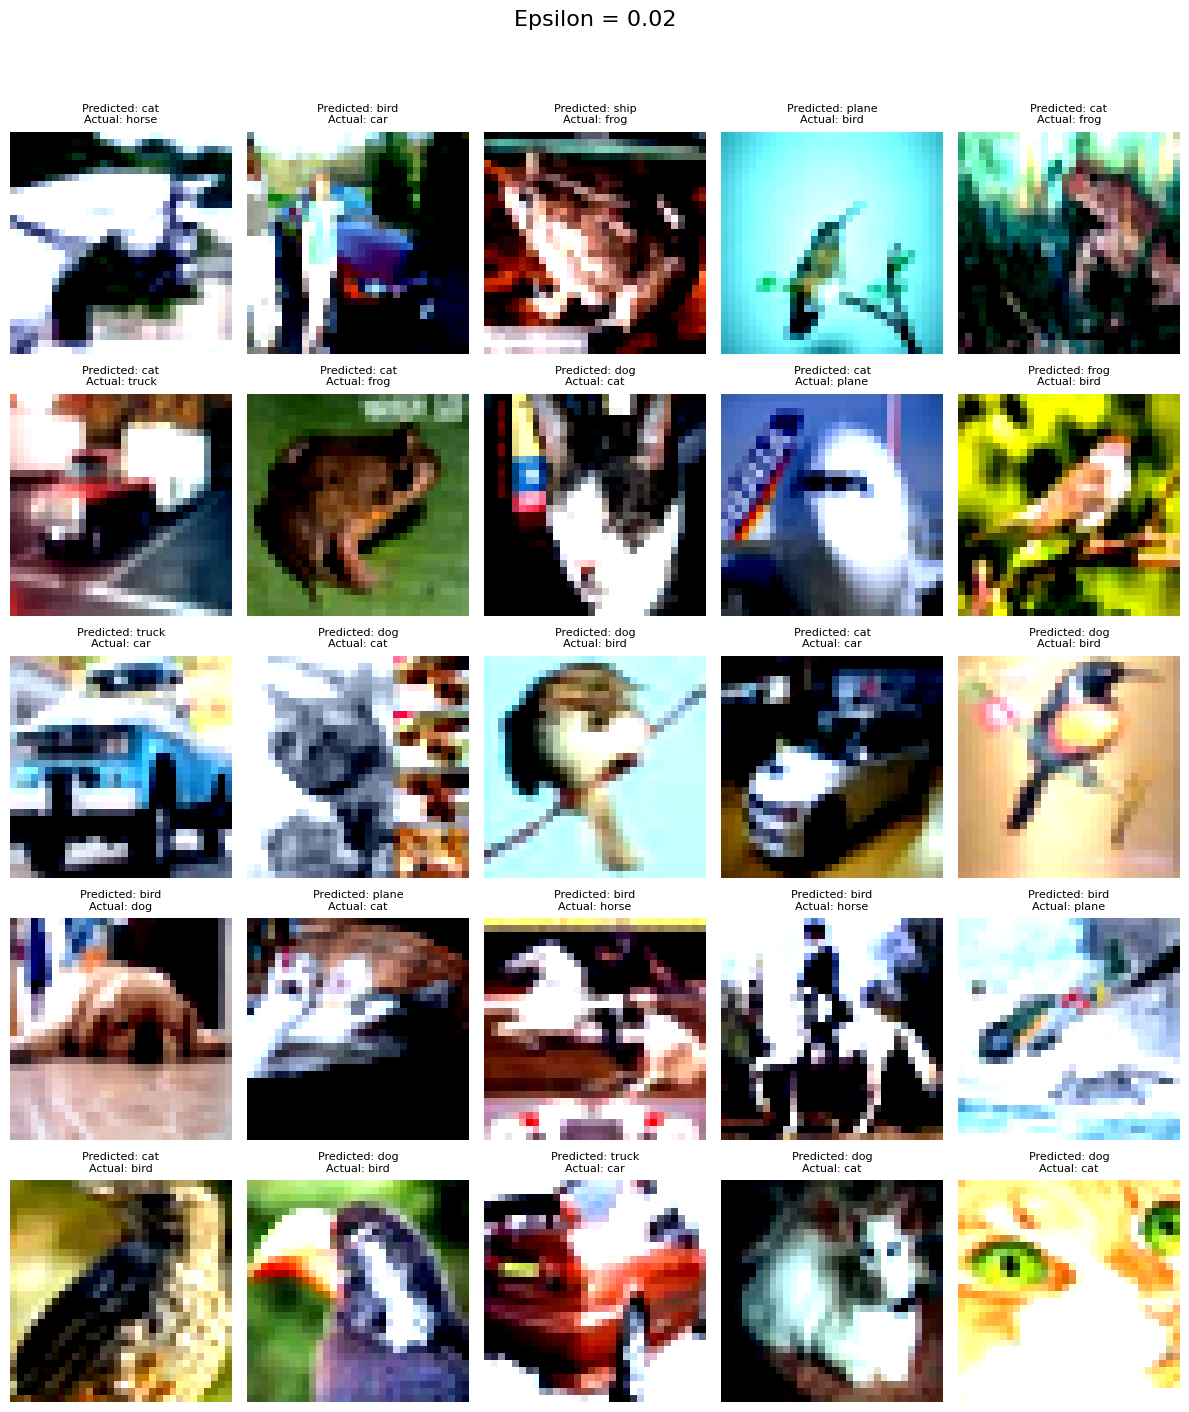

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2902661..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4828431..1.5131432].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5178571..1.7589979].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.37057972..1.6892812].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.21148455..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.24214405..1.6282789].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0023974776..1

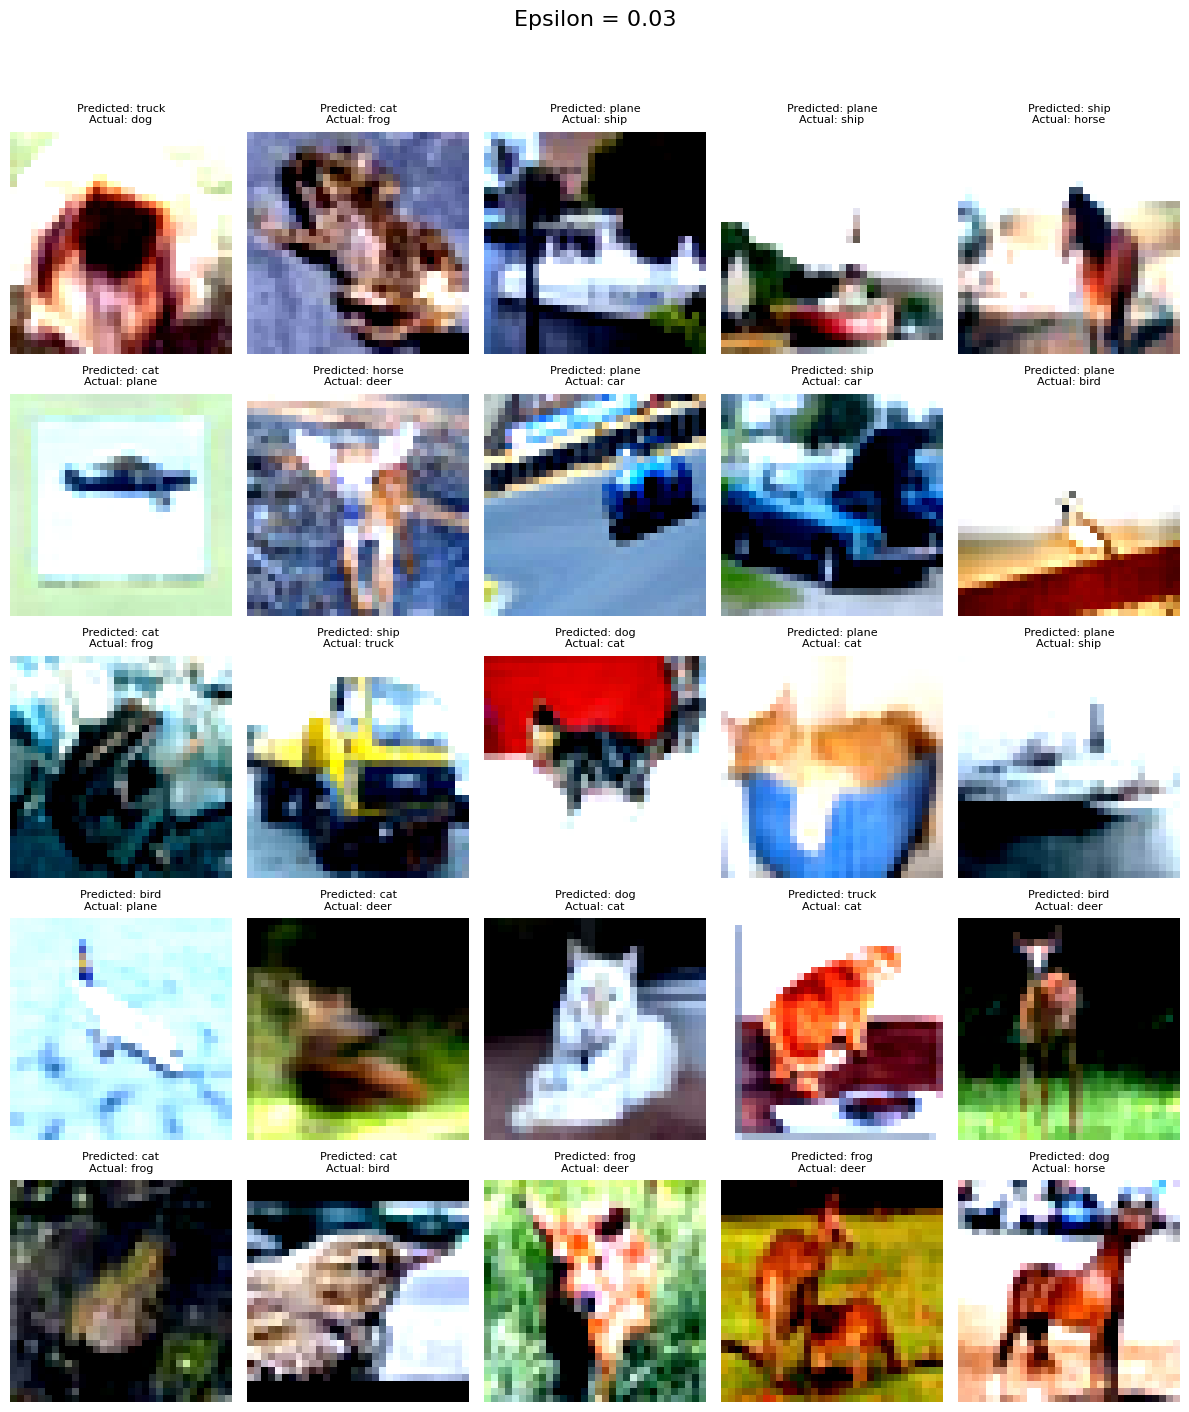

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.490453..1.4360819].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.49901533..0.870965].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.418957].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.44764107..1.4452724].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.48189062..1.3755556].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.31920546..1.2678571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.541827

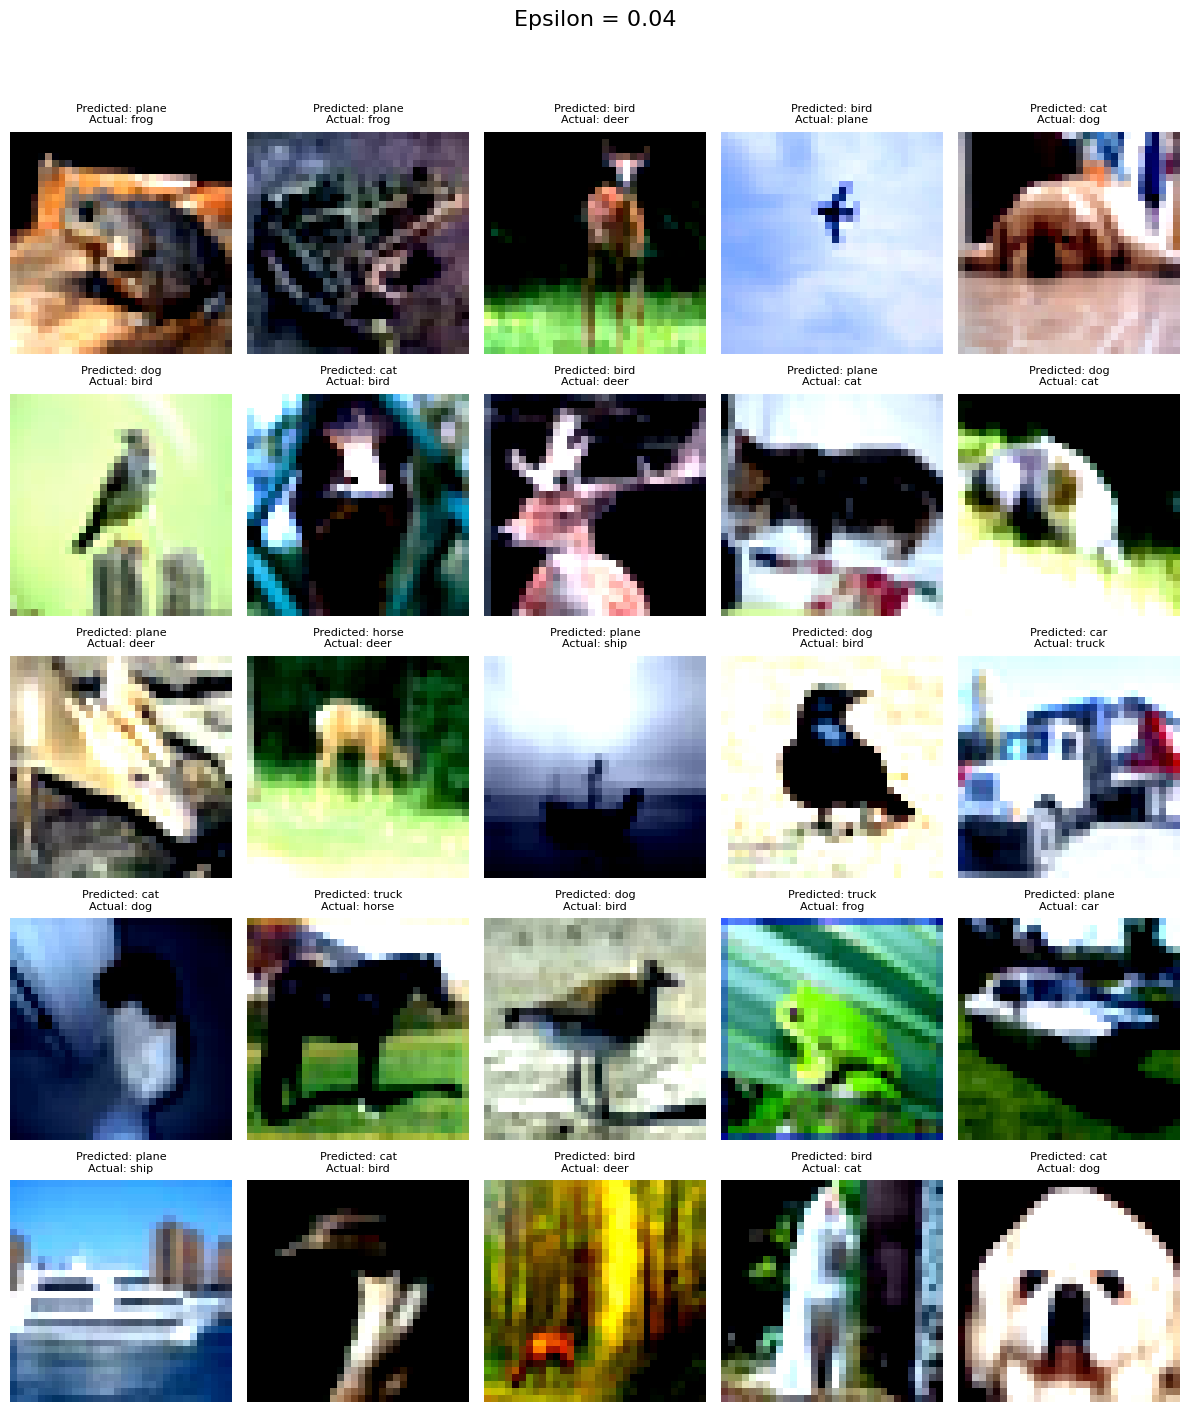

In [39]:
def ax_imshow(ax, img, predicted, actual):
    # Unnormalize the image if it was normalized
    img = img / 2 + 0.5  # Reversing normalization (if applicable)
    npimg = img.numpy()
    ax.imshow(np.transpose(npimg, (1, 2, 0)))
    
    # Display class names instead of numeric labels
    predicted_class = classes[predicted]
    actual_class = classes[actual]
    
    ax.set_title(f'Predicted: {predicted_class}\nActual: {actual_class}', fontsize=8)
    ax.axis('off')

# Display 5x5 matrix of original images with predicted and actual labels for each epsilon
for i, epsilon in enumerate(epsilons):
    fig, axs = plt.subplots(5, 5, figsize=(12, 15))  # Create 5x5 grid
    fig.suptitle(f"Epsilon = {epsilon}", fontsize=16)
    
    # Iterate over the examples for each epsilon
    for j in range(len(examples[i])): 
        orig, adv, adv_ex, ori_ex = examples[i][j]
        
        # Plot the original image
        ax = axs[j // 5, j % 5]  # Calculate position in grid
        
        # Display original image with both predicted and actual class names
        ax_imshow(ax, ori_ex, predicted=adv, actual=orig)  # Predicted label from adversarial, actual label from original
        
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout for better spacing
    plt.show()


In [ ]:
def mifgsm_attack(image, epsilon, data_grad, alpha, num_iter, decay_factor):
    # Copy the original image
    perturbed_image = image.clone()
    g = torch.zeros_like(image)  # Initialize momentum term

    for i in range(num_iter):
        # Ensure the image is unnormalized for each iteration
        perturbed_image = unnormalize(perturbed_image)

        # Update the momentum term
        g = decay_factor * g + data_grad / torch.norm(data_grad, p=1)

        # Compute the perturbation using the momentum
        perturbed_image = perturbed_image + alpha * g.sign()

        # Clip the perturbation to maintain within the allowed epsilon bounds
        perturbation = torch.clamp(perturbed_image - image, min=-epsilon, max=epsilon)
        perturbed_image = image + perturbation

        # Re-normalize the image to maintain its integrity within the input space
        perturbed_image = torch.clamp(perturbed_image, 0, 1)  # Ensure pixel values are valid
        perturbed_image = transforms.Normalize(mean=norm_mean, std=norm_std)(perturbed_image)

    return perturbed_image.float()


In [42]:
def mifgsm_test(model, data_loader, epsilon, n_examples, alpha, num_iter, decay_factor=1.0):
    '''
    Perform MI-FGSM attack and test the model's accuracy.
    
    Args:
    - model: The neural network model.
    - data_loader: The data loader (batch size = 1).
    - epsilon: Maximum allowed perturbation.
    - n_examples: Number of adversarial examples to store for visualization.
    - alpha: Step size for each iteration.
    - num_iter: Number of iterations for MI-FGSM.
    - decay_factor: Momentum decay factor.
    
    Returns:
    - final_acc: Accuracy of the model on adversarial examples.
    - adv_examples: List of adversarial examples.
    '''
    print('Epsilon:', epsilon)
    print('-' * 10)
    correct = 0
    adv_examples = []
    
    for i, (data, target) in enumerate(data_loader):
        
        if i > 0 and i % 1000 == 0:
            current_acc = correct / i
            print(f'Test Accuracy = {current_acc:.4f} [{i:>5d} / {len(data_loader):>5d}]')

        # Send the data and label to the device
        data, target = data.to(device), target.to(device)

        # Set requires_grad attribute of tensor
        data.requires_grad = True

        # Forward pass the data through the model
        output = model(data)
        init_pred = output.max(1, keepdim=True)[1]

        # If the initial prediction is wrong, skip the attack
        if init_pred.item() != target.item():
            continue

        # Calculate the loss
        loss = F.nll_loss(output, target)

        # Zero all existing gradients
        model.zero_grad()

        # Calculate gradients of model in backward pass
        loss.backward()

        # Collect the gradients
        data_grad = data.grad.data

        # Perform MI-FGSM attack
        perturbed_data = mifgsm_attack(data, epsilon, data_grad, alpha, num_iter, decay_factor)

        # Re-classify the perturbed image
        output = model(perturbed_data)

        # Check for success
        final_pred = output.max(1, keepdim=True)[1]
        if final_pred.item() == target.item():
            correct += 1
            if (epsilon == 0) and (len(adv_examples) < n_examples):
                adv_ex = perturbed_data.squeeze().detach().cpu()
                ori_ex = data.squeeze().detach().cpu()
                adv_examples.append((init_pred.item(), final_pred.item(), adv_ex, ori_ex))
        else:
            if len(adv_examples) < n_examples:
                adv_ex = perturbed_data.squeeze().detach().cpu()
                ori_ex = data.squeeze().detach().cpu()
                adv_examples.append((init_pred.item(), final_pred.item(), adv_ex, ori_ex))

    # Calculate final accuracy for this epsilon
    final_acc = correct / float(len(data_loader))
    print(f"Epsilon: {epsilon}\tTest Accuracy = {correct} / {len(data_loader)} = {final_acc}\n")

    return final_acc, adv_examples


In [43]:
epsilons = [0.001, 0.01, 0.02, 0.03, 0.04]  # Updated epsilon values
n_examples = 25
examples = []
accuracies = []

# Parameters for MI-FGSM
alpha = 0.005  # Step size for each iteration
num_iter = 10  # Number of iterations
decay_factor = 1.0  # Momentum decay factor

# Run test for each epsilon using MI-FGSM
for eps in epsilons:
    acc, ex = mifgsm_test(model, test_loader_1, eps, n_examples, alpha, num_iter, decay_factor)
    accuracies.append(acc)
    examples.append(ex)


Epsilon: 0.001
----------
Test Accuracy = 0.3840 [ 1000 / 10000]
Test Accuracy = 0.3680 [ 2000 / 10000]
Test Accuracy = 0.3720 [ 3000 / 10000]
Test Accuracy = 0.3752 [ 4000 / 10000]
Test Accuracy = 0.3754 [ 5000 / 10000]
Test Accuracy = 0.3703 [ 6000 / 10000]
Test Accuracy = 0.3704 [ 7000 / 10000]
Test Accuracy = 0.3683 [ 8000 / 10000]
Test Accuracy = 0.3712 [ 9000 / 10000]
Epsilon: 0.001	Test Accuracy = 3705 / 10000 = 0.3705

Epsilon: 0.01
----------
Test Accuracy = 0.3620 [ 1000 / 10000]
Test Accuracy = 0.3695 [ 2000 / 10000]
Test Accuracy = 0.3807 [ 3000 / 10000]
Test Accuracy = 0.3760 [ 4000 / 10000]
Test Accuracy = 0.3752 [ 5000 / 10000]
Test Accuracy = 0.3720 [ 6000 / 10000]
Test Accuracy = 0.3720 [ 7000 / 10000]
Test Accuracy = 0.3729 [ 8000 / 10000]
Test Accuracy = 0.3727 [ 9000 / 10000]
Epsilon: 0.01	Test Accuracy = 3710 / 10000 = 0.371

Epsilon: 0.02
----------
Test Accuracy = 0.3610 [ 1000 / 10000]
Test Accuracy = 0.3675 [ 2000 / 10000]
Test Accuracy = 0.3660 [ 3000 / 10000]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.37780112..1.323268].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.46476585..1.8025708].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5332649..1.6282789].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.35345495..1.5934205].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4390756..1.5392157].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5418272..1.5324184].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.20309

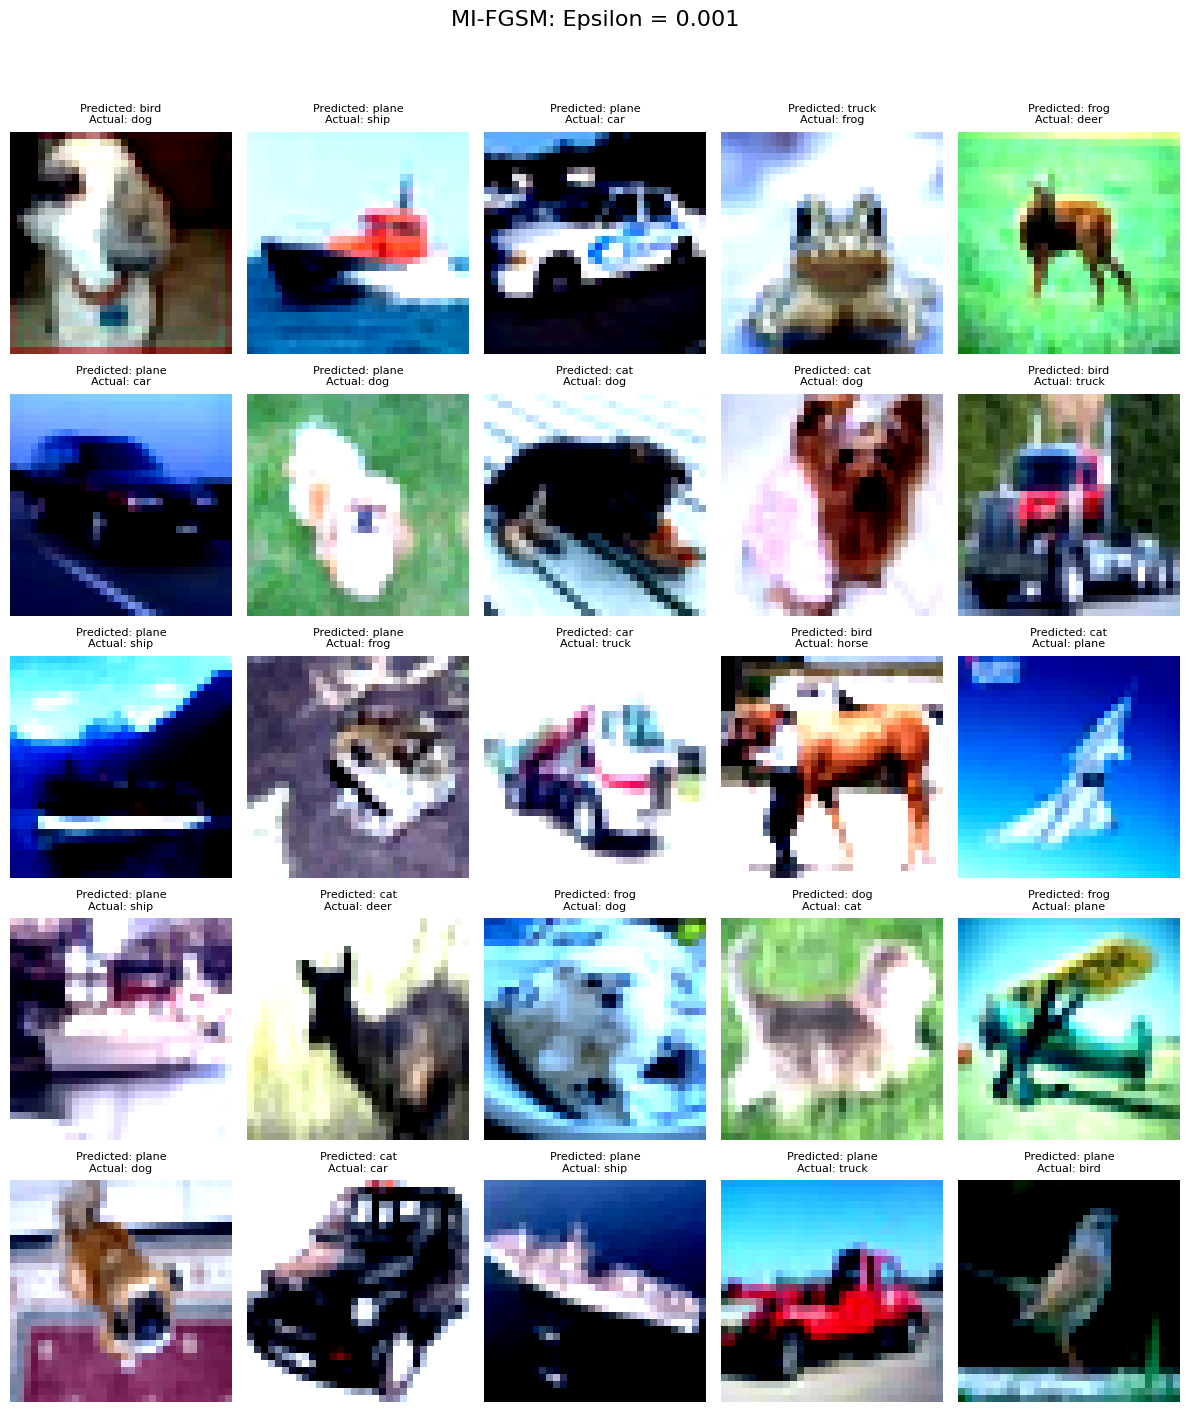

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.0618302].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.8112855].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5332649..1.3929849].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.36904758..1.2535512].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.4714162].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.49901533..1.2099783].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4647658

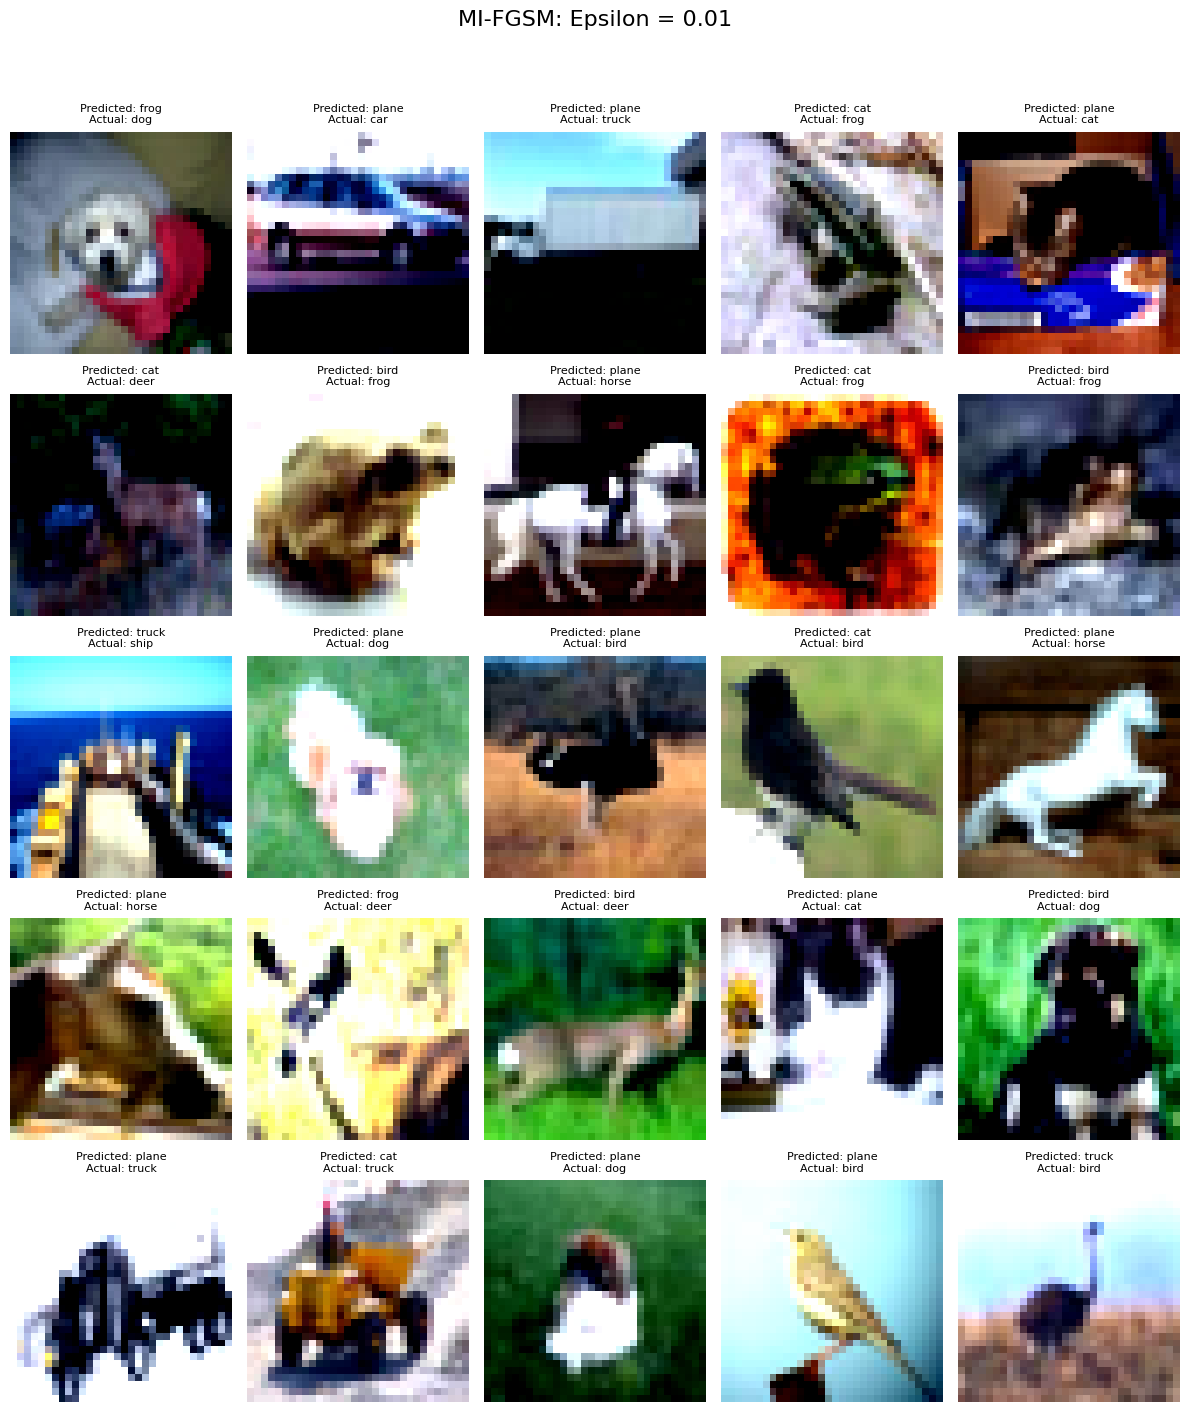

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.6021352].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.080182016..1.4191287].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.5304621].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.16692811..0.92647064].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.3673638..1.7067103].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.07089651..1.7764271].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.276

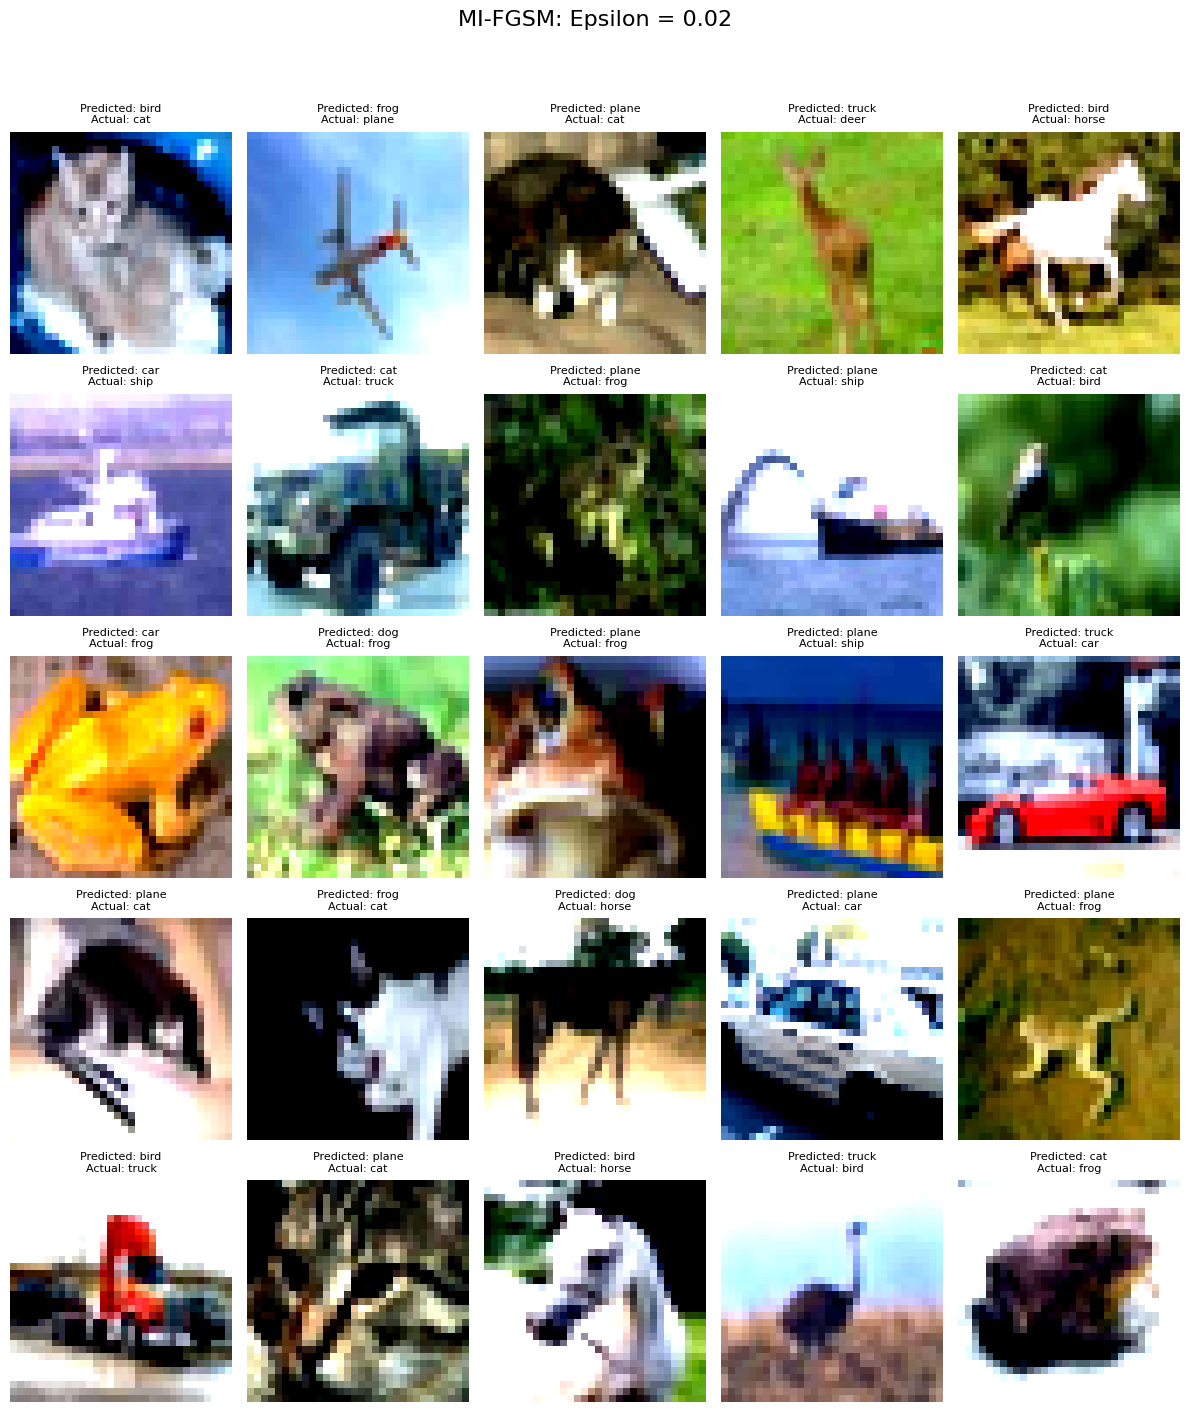

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4048292..1.5934205].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.21050107..1.584706].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.34489256..1.7938564].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4133916..1.1803222].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5418272..1.0935868].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.7502832].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952

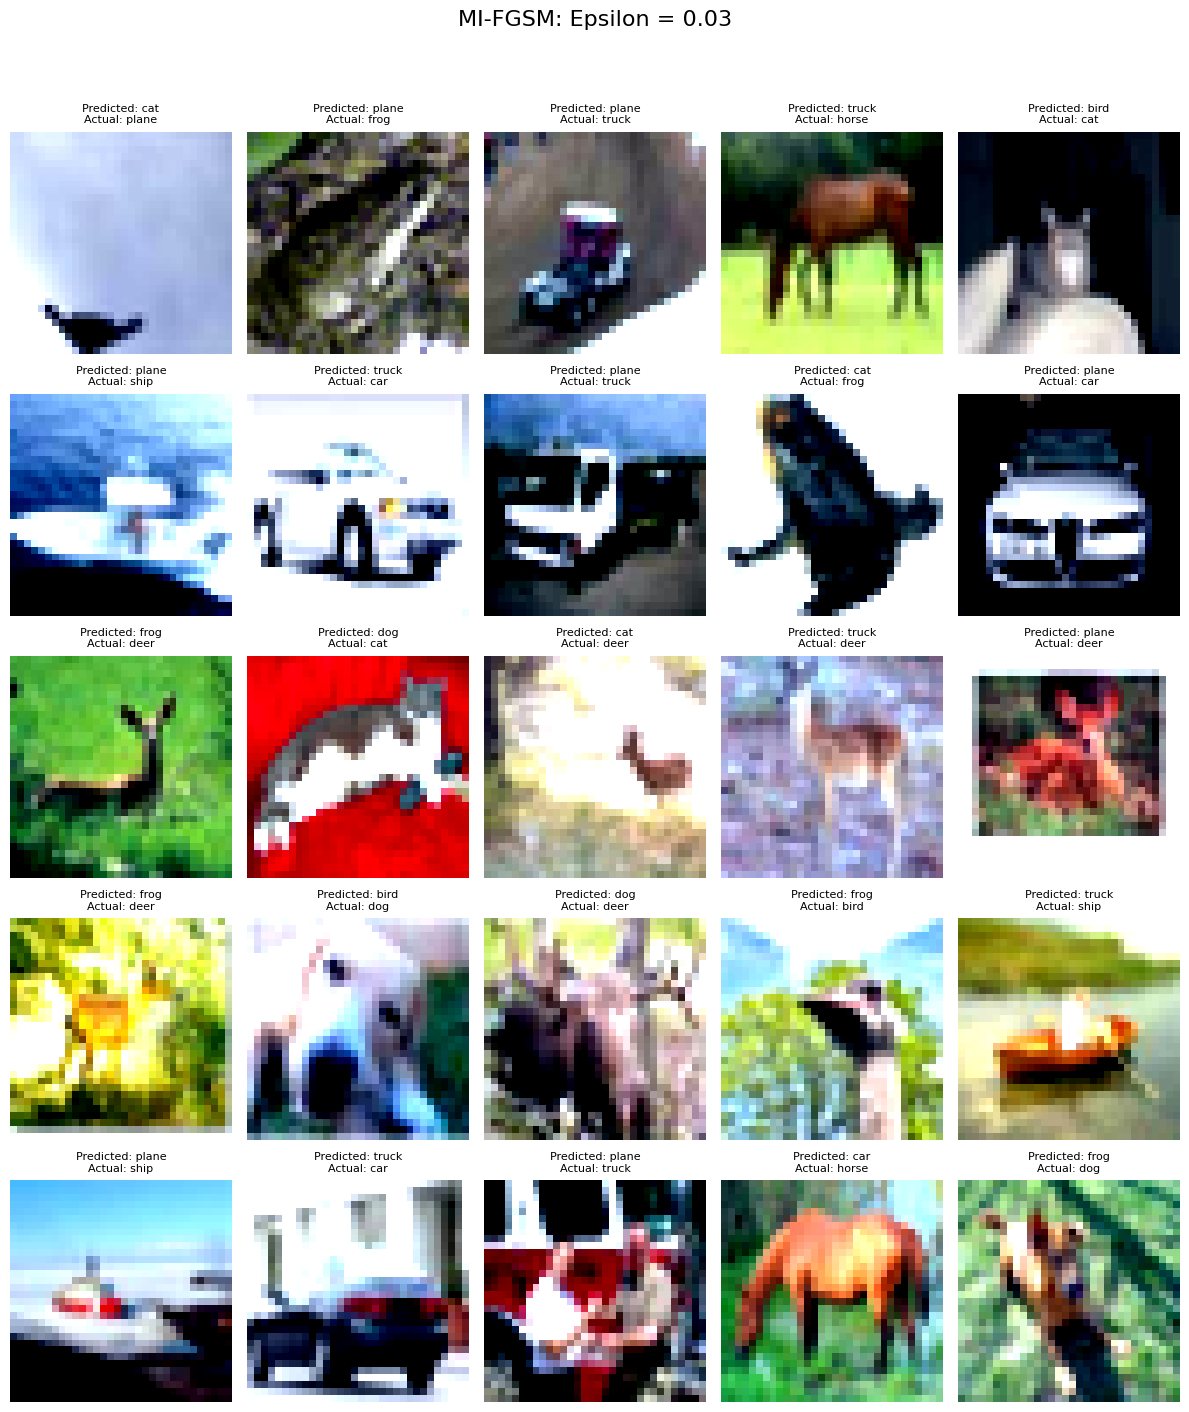

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.44782913..1.6244541].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.0165254].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.7502832].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.36904758..1.6073294].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.38770443..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.08802128..1.7067

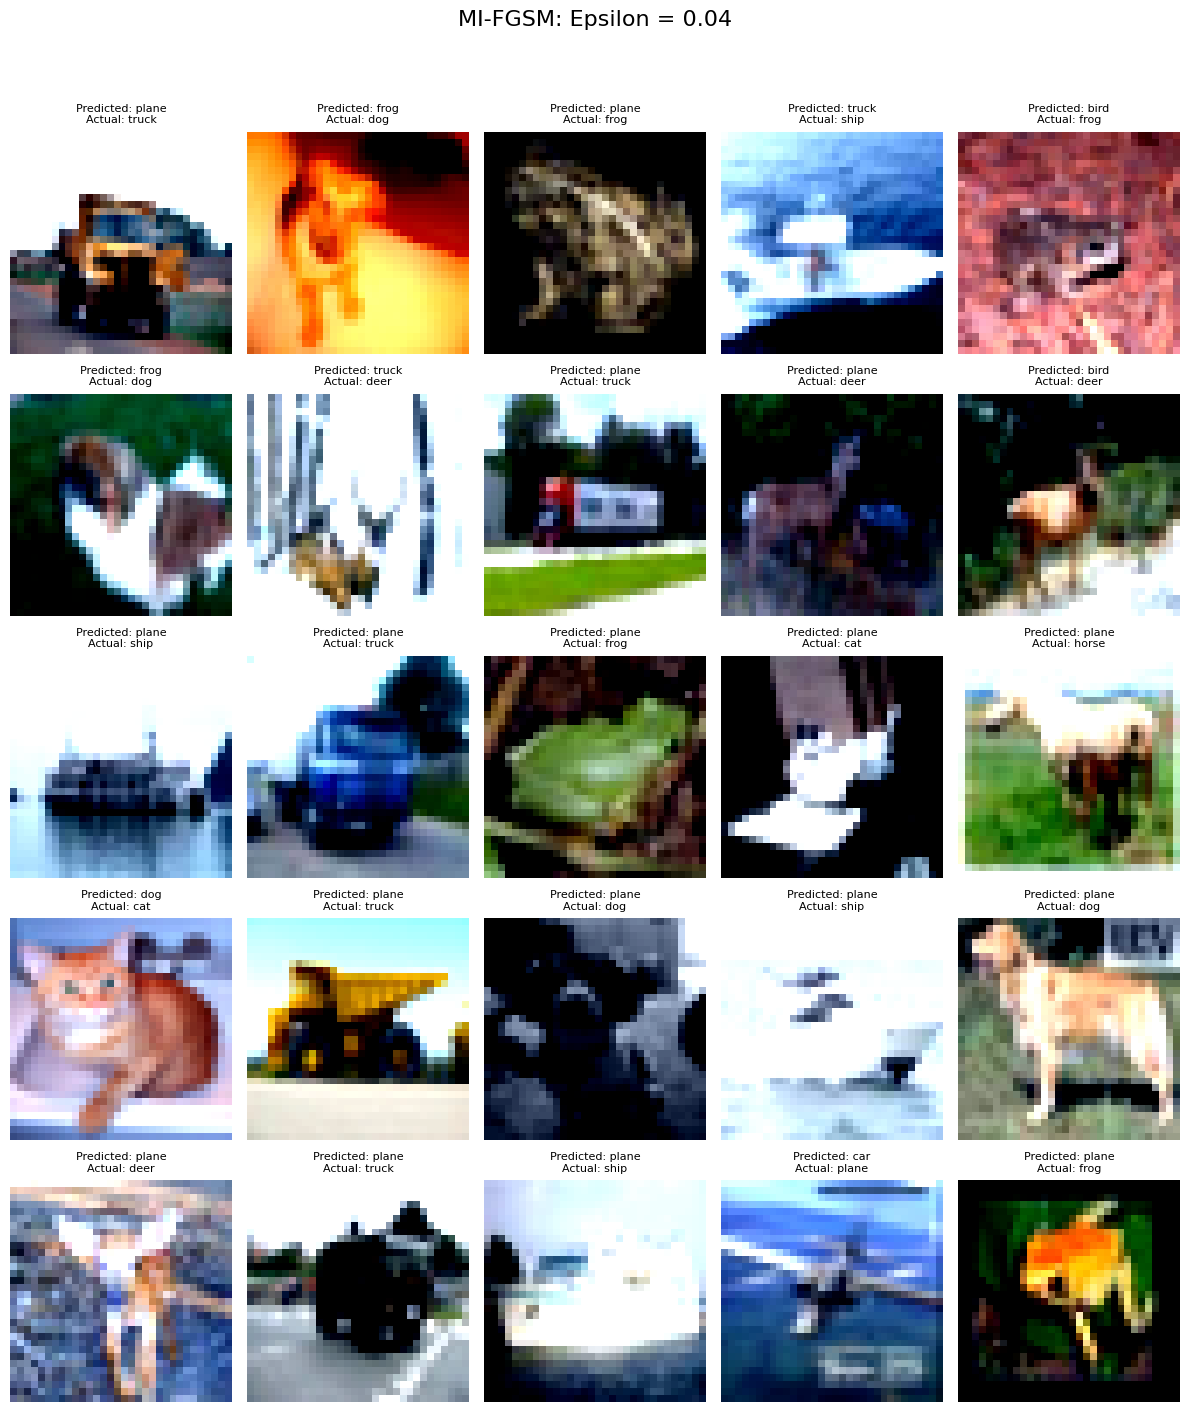

In [45]:
def ax_imshow(ax, img, predicted, actual):
    # Unnormalize the image if it was normalized
    img = img / 2 + 0.5  # Reversing normalization (if applicable)
    npimg = img.numpy()
    ax.imshow(np.transpose(npimg, (1, 2, 0)))
    
    # Display class names instead of numeric labels
    predicted_class = classes[predicted]
    actual_class = classes[actual]
    
    ax.set_title(f'Predicted: {predicted_class}\nActual: {actual_class}', fontsize=8)
    ax.axis('off')

# Display 5x5 matrix of original images with predicted and actual labels for each epsilon (MI-FGSM)
for i, epsilon in enumerate(epsilons):
    fig, axs = plt.subplots(5, 5, figsize=(12, 15))  # Create 5x5 grid
    fig.suptitle(f"MI-FGSM: Epsilon = {epsilon}", fontsize=16)  # Title indicating MI-FGSM
    
    # Iterate over the examples for each epsilon
    for j in range(len(examples[i])): 
        orig, adv, adv_ex, ori_ex = examples[i][j]
        
        # Plot the original image
        ax = axs[j // 5, j % 5]  # Calculate position in grid
        
        # Display original image with both predicted and actual class names
        ax_imshow(ax, ori_ex, predicted=adv, actual=orig)  # Predicted label from adversarial, actual label from original
        
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout for better spacing
    plt.show()
